# 01. Данные и дизайн исследования GraphProg

Основная задача — прогноз успешности первого запуска при первом посещении задания RoboMission. Единица наблюдения — первое посещение пары учащийся–задание; момент прогноза — начало посещения. Предполагается, что уже наблюдаемая история программ и действий дополняет сведения о текущем задании.

Дополнительная цель — число запусков до первого успеха с учётом правого цензурирования. Школьные pre/post cCTt анализируются отдельно: индивидуальная связь между двумя источниками отсутствует.

В этом блокноте определяются состав выборок, качество измерений и разбиения. Обучение моделей начинается в блокноте 03.

In [1]:
from pathlib import Path
import json
import hashlib
import urllib.request
import urllib.error


def verify_frozen_training_source(root: Path) -> None:
    """Verify frozen training code before reproducing the recorded evaluation."""
    boundary = root / "dataset/protocol/test_evaluation_boundary.json"
    if not boundary.exists():
        return
    frozen_sources = json.loads(
        (root / "dataset/protocol/frozen_training_sources.json").read_text()
    )
    for filename, expected in frozen_sources["notebooks"].items():
        notebook = json.loads((root / "notebooks" / filename).read_text())
        source = "\n\n".join(
            "".join(cell["source"])
            for cell in notebook["cells"]
            if cell["cell_type"] == "code"
        )
        observed = hashlib.sha256(source.encode()).hexdigest()
        assert (
            observed == expected
        ), "Training source changed after the test was opened."


import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager
from IPython.display import display, Markdown


def resolve_project_root(start: Path) -> Path:
    """Find the repository from its root or any notebook subdirectory."""
    for candidate in (start.resolve(), *start.resolve().parents):
        if (
            (candidate / "notebooks").is_dir()
            and (candidate / "dataset/raw").is_dir()
            and (candidate / "requirements.txt").is_file()
        ):
            return candidate
    raise FileNotFoundError(
        "Start Jupyter from the GraphProg repository or its notebooks directory."
    )


ROOT = resolve_project_root(Path.cwd())
for relative in (
    "dataset/processed",
    "dataset/protocol",
    "artifacts/runtime",
    "figures/generated",
):
    (ROOT / relative).mkdir(parents=True, exist_ok=True)

SEED = 20260923
rng = np.random.default_rng(SEED)
font_names = {font.name for font in font_manager.fontManager.ttflist}
assert "Times New Roman" in font_names
FONT = "Times New Roman"
FONT_SIZE, TITLE_SIZE, FIGURE_DPI = 18, 20, 350
mpl.rcParams.update(
    {
        "font.family": FONT,
        "font.size": 18,
        "axes.titlesize": 20,
        "axes.labelsize": 18,
        "xtick.labelsize": 18,
        "ytick.labelsize": 18,
        "legend.fontsize": 18,
        "figure.dpi": 350,
        "savefig.dpi": 350,
        "axes.unicode_minus": True,
        "mathtext.fontset": "stix",
    }
)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)


def table(frame: pd.DataFrame, caption: str, name: str) -> None:
    """Display a complete DataFrame using Jupyter's default table styling."""
    frame.to_csv(ROOT / "artifacts" / f"{name}.csv", index=False)
    with pd.option_context(
        "display.max_rows",
        None,
        "display.max_columns",
        None,
        "display.max_colwidth",
        None,
        "display.width",
        None,
    ):
        display(Markdown(caption))
        display(frame.reset_index(drop=True).round(3))


def save_figure(fig: mpl.figure.Figure, name: str) -> None:
    """Save at 350 dpi after checking the font contract on visible text."""
    from matplotlib.text import Text

    fig.canvas.draw()
    for text in fig.findobj(match=Text):
        if text.get_visible() and text.get_text():
            assert 18 <= text.get_fontsize() <= 20
            assert text.get_fontfamily() == ["Times New Roman"]
    fig.savefig(ROOT / "figures/generated" / f"{name}.png", dpi=FIGURE_DPI)
    fig.savefig(ROOT / "figures/generated" / f"{name}.pdf", dpi=FIGURE_DPI)


verify_frozen_training_source(ROOT)


In [2]:
raw = ROOT / "dataset" / "raw" / "zenodo_7489244"
record_url = "https://zenodo.org/api/records/7489244"
if not (raw / "record.json").exists():
    (raw / "record.json").write_bytes(
        urllib.request.urlopen(record_url, timeout=30).read()
    )
record = json.loads((raw / "record.json").read_text())
manifest = []
for item in record["files"]:
    path = raw / item["key"]
    if not path.exists():
        path.write_bytes(
            urllib.request.urlopen(item["links"]["self"], timeout=40).read()
        )
    blob = path.read_bytes()
    assert "md5:" + hashlib.md5(blob).hexdigest() == item["checksum"]
    manifest.append(
        {
            "file": str(path.relative_to(ROOT)),
            "source": item["links"]["self"],
            "bytes": len(blob),
            "sha256": hashlib.sha256(blob).hexdigest(),
            "source_md5": item["checksum"],
        }
    )
(ROOT / "dataset/protocol" / "source_manifest.json").write_text(
    json.dumps(manifest, indent=2)
)
datasets = {p.stem: pd.read_csv(p) for p in sorted(raw.glob("*.csv"))}
assert len(datasets) == 3
school = datasets["student_test_janjune_2021"].copy()
required = [
    "City",
    "School",
    "Class",
    "Pre-test cCTt score",
    "Post-test cCTt score",
    "Students' grade",
    "Students' gender",
]
assert set(required).issubset(school.columns)
assert school["Unnamed: 0"].is_unique
school = school.rename(columns={"Unnamed: 0": "source_row"})
# This index preserves source identity; it is not a cross-source learner identifier.
import zipfile

robo_raw = ROOT / "dataset/raw/robomission"
robo_archive = robo_raw / "robomission-2019-12-10.zip"
robo_directory = robo_raw / "robomission-2019-12-10"
with zipfile.ZipFile(robo_archive) as compressed:
    for filename in ("events.csv", "attempts.csv", "problems.csv"):
        target = robo_directory / filename
        if not target.exists():
            members = [
                name
                for name in compressed.namelist()
                if name.rstrip("/").split("/")[-1] == filename
            ]
            assert len(members) == 1
            target.parent.mkdir(parents=True, exist_ok=True)
            with compressed.open(members[0]) as incoming, target.open(
                "wb"
            ) as outgoing:
                import shutil

                shutil.copyfileobj(incoming, outgoing)

robo_paths = [
    p for p in (ROOT / "dataset" / "raw" / "robomission").rglob("*.csv")
]
robo_present = {"events.csv", "attempts.csv", "problems.csv"}.issubset(
    {p.name for p in robo_paths}
)


## Состав источников

Какие наблюдаемые результаты действительно представлены в каждом файле? Размеры ниже вычисляются из файлов и могут отличаться от численности аналитических выборок.

In [3]:
rows = []
roles = {
    "student_test_janjune_2021": "Продольный cCTt: январь — июнь 2021",
    "student_surveytest_nov_2021": "Срез cCTt и восприятия: ноябрь 2021",
    "student_survey_may_2022": "Восприятие: май 2022",
}
for name, frame in datasets.items():
    rows.append(
        {
            "Источник": roles[name],
            "Строк": len(frame),
            "Столбцов": frame.shape[1],
            "Школ": frame["School"].nunique(),
            "Классов (метки)": frame["Class"].nunique(),
        }
    )
table(
    pd.DataFrame(rows),
    "Таблица 1. Фактический состав школьных данных",
    "01_source_composition",
)


Таблица 1. Фактический состав школьных данных

,Источник,Строк,Столбцов,Школ,Классов (метки)
0,Восприятие: май 2022,1644,30,5,85
1,Срез cCTt и восприятия: ноябрь 2021,2456,45,7,130
2,Продольный cCTt: январь — июнь 2021,1470,46,7,83


В файлах 1 644, 2 456 и 1 470 строк соответственно; эти значения характеризуют выгрузку, а не аналитические выборки.

## Полнота продольных наблюдений

Отсутствующие цели не восстанавливаются импутацией. Строки с одинаковыми наблюдаемыми баллами не удаляются как дубликаты учеников: в анонимизированном наборе совпадения возможны. Нумерация строк не используется как предиктор.

In [4]:
pre, post = "Pre-test cCTt score", "Post-test cCTt score"
for col in [pre, post]:
    observed = school[col].dropna()
    assert (
        observed.between(0, 24).all()
        and np.equal(observed, observed.round()).all()
    )
eligible = school[school[pre].notna() & school[post].notna()].copy()
quality = pd.DataFrame(
    [
        ["Все строки", len(school)],
        ["Предварительный балл отсутствует", int(school[pre].isna().sum())],
        ["Итоговый балл отсутствует", int(school[post].isna().sum())],
        ["Оба балла доступны", len(eligible)],
        [
            "Повторные индексы исходных строк",
            int(school.source_row.duplicated().sum()),
        ],
        [
            "Полностью совпадающие строки без индекса",
            int(school.drop(columns="source_row").duplicated().sum()),
        ],
    ],
    columns=["Характеристика", "Число"],
)
table(
    quality,
    "Таблица 2. Полнота и повторяемость продольных наблюдений",
    "01_longitudinal_quality",
)


Таблица 2. Полнота и повторяемость продольных наблюдений

,Характеристика,Число
0,Все строки,1470
1,Предварительный балл отсутствует,7
2,Итоговый балл отсутствует,7
3,Оба балла доступны,1463
4,Повторные индексы исходных строк,0
5,Полностью совпадающие строки без индекса,51


В продольном файле 1 463 полных пары баллов. 51 совпадающая строка без индекса сохранена: без идентификатора учащегося нельзя доказать повторную запись одного человека.

## Временная доступность признаков

README источника относит teacher perception к январю, до предварительного теста, а teacher adoption к июню, после итогового теста. Для основного школьного протокола разрешены pre-test, класс обучения и 16 показателей восприятия/мотивации учителя. Пол ученика используется только для анализа подгрупп. Оценки программы повышения квалификации исключены консервативно, поскольку их отдельная временная принадлежность не специфицирована.

In [5]:
teacher_cols = [
    c
    for c in school
    if c.startswith("The teachers' perception")
    or c.startswith("Autonomous motivation")
]
features = [pre, "Students' grade"] + teacher_cols
assert len(teacher_cols) == 16
for c in teacher_cols:
    assert school[c].dropna().between(-3, 3).all()
assert not any(
    "Number of periods" in c or "Post-test" in c or "change" in c
    for c in features
)
feature_contract = {
    "features": features,
    "target": post,
    "pretest": pre,
    "teacher_features": teacher_cols,
    "group_columns": ["City", "School"],
    "sensitive_analysis_only": ["Students' gender"],
    "exclude": [c for c in school if c not in features + [post]],
}
(ROOT / "dataset/protocol" / "school_features.json").write_text(
    json.dumps(feature_contract, ensure_ascii=False, indent=2)
)
table(
    pd.DataFrame(
        [
            ["Предварительный cCTt и класс", 2, "До прогноза", "Вход"],
            [
                "Восприятие и мотивация учителя",
                len(teacher_cols),
                "Январь 2021",
                "Вход",
            ],
            [
                "Количество проведённых занятий",
                sum(c.startswith("Number of periods") for c in school),
                "Июнь, после post-test",
                "Исключены",
            ],
            [
                "Оценка повышения квалификации",
                sum(c.startswith("The teachers' CS PD") for c in school),
                "Отдельно не установлено",
                "Исключены",
            ],
            ["Итоговый cCTt", 1, "Июнь 2021", "Цель"],
            [
                "Изменение балла",
                1,
                "Использует итоговую цель",
                "Исключено из входов",
            ],
        ],
        columns=["Группа", "Признаков", "Доступность", "Роль"],
    ),
    "Таблица 3. Прогнозный контракт",
    "01_feature_availability",
)


Таблица 3. Прогнозный контракт

,Группа,Признаков,Доступность,Роль
0,Предварительный cCTt и класс,2,До прогноза,Вход
1,Восприятие и мотивация учителя,16,Январь 2021,Вход
2,Количество проведённых занятий,15,"Июнь, после post-test",Исключены
3,Оценка повышения квалификации,6,Отдельно не установлено,Исключены
4,Итоговый cCTt,1,Июнь 2021,Цель
5,Изменение балла,1,Использует итоговую цель,Исключено из входов


Вход ограничен 18 признаками; 15 показателей проведённых занятий и 6 оценок повышения квалификации исключены. Это предотвращает включение будущих измерений.

## Фиксированное разбиение по школам

Школы назначаются по детерминированному хешу идентификатора и seed, без выбора по баллам. Две школы предназначены для закрытой финальной оценки, одна — для валидации, остальные — для обучения. Во внутренних фолдах исключается целая школа. Препроцессинг обучается внутри фолда. Такой небольшой набор школ ограничивает точность оценки межшкольного переноса; один validation-school не заменяет внешнюю репликацию. Тестовые баллы далее не анализируются.

In [6]:
eligible["school_group"] = (
    eligible[["City", "School"]].astype(str).agg("|".join, axis=1)
)
eligible["class_group"] = (
    eligible[["City", "School", "Class"]].astype(str).agg("|".join, axis=1)
)
groups = sorted(
    eligible.school_group.unique(),
    key=lambda g: hashlib.sha256(f"{SEED}:{g}".encode()).hexdigest(),
)
assert len(groups) >= 7
assignment = {
    g: ("locked_test" if i < 2 else "validation" if i == 2 else "train")
    for i, g in enumerate(groups)
}
eligible["split"] = eligible.school_group.map(assignment)
split_manifest = eligible[
    ["source_row", "school_group", "class_group", "split"]
]
manifest_path = ROOT / "dataset/protocol" / "school_split.csv"
if manifest_path.exists():
    pd.testing.assert_frame_equal(
        pd.read_csv(manifest_path),
        split_manifest.reset_index(drop=True),
        check_dtype=False,
    )
else:
    split_manifest.to_csv(manifest_path, index=False)
for part in ["train", "validation", "locked_test"]:
    eligible[eligible.split == part].to_pickle(
        ROOT / "dataset" / "processed" / f"school_{part}.pkl"
    )
train = eligible[eligible.split == "train"]
assert train.school_group.nunique() >= 3
summary = (
    eligible.groupby("split")
    .agg(
        Ученики=("source_row", "size"),
        Школы=("school_group", "nunique"),
        Классы=("class_group", "nunique"),
    )
    .reset_index()
)
table(summary, "Таблица 4. Разбиение без пересечения школ", "01_school_split")
protocol = {
    "seed": SEED,
    "primary_metric": "MAE",
    "secondary_metrics": ["RMSE", "R2"],
    "seeds": [17, 42, 2026],
    "inner_cv": "LeaveOneGroupOut by school on train",
    "validation": "One held-out school; selection evidence is exploratory",
    "locked_test": "Two held-out schools; do not read during development",
    "split_sha256": hashlib.sha256(manifest_path.read_bytes()).hexdigest(),
    "robo_data_available": robo_present,
    "no_linkage_between_sources": True,
}
(ROOT / "dataset/protocol" / "school_protocol.json").write_text(
    json.dumps(protocol, indent=2)
);


Таблица 4. Разбиение без пересечения школ

,split,Ученики,Школы,Классы
0,locked_test,397,2,21
1,train,909,4,52
2,validation,157,1,9


Школьное разбиение содержит 909 обучающих, 157 валидационных и 397 закрытых тестовых наблюдений. Обобщение по школам ограничено их малым числом.

## Реальный архив RoboMission

Получен архив от 10 декабря 2019 года из публичной папки, на которую ссылается [официальный исследовательский репозиторий](https://github.com/adaptive-learning/adaptive-learning-research/tree/master/data/robomission-2019-02-09). Название раздела репозитория относится к февралю, но в связанной папке доступны оба архива. Используется только декабрьская версия; перекрывающийся февральский архив не является независимой внешней проверкой.

Таблица попыток — агрегат событий. Финальные поля попытки запрещены в признаках этой же попытки. События редактирования не имеют метки правильности. Возраст и принадлежность к поколению Альфа здесь не подтверждены.

In [7]:
import zipfile

robo_raw = ROOT / "dataset" / "raw" / "robomission"
archive = robo_raw / "robomission-2019-12-10.zip"
assert zipfile.is_zipfile(archive)
robo_dir = robo_raw / "robomission-2019-12-10"
events = pd.read_csv(robo_dir / "events.csv")
attempts = pd.read_csv(robo_dir / "attempts.csv")
problems = pd.read_csv(robo_dir / "problems.csv")
assert {
    "id",
    "event_order",
    "timestamp",
    "event_type",
    "student",
    "problem",
    "attempt",
    "program",
    "correct",
}.issubset(events)
assert events.id.is_unique and attempts.id.is_unique and problems.id.is_unique
assert (
    events.attempt.isin(attempts.id).all()
    and events.problem.isin(problems.id).all()
)
assert (
    not events[["student", "problem", "attempt", "timestamp"]]
    .isna()
    .any()
    .any()
)
events["timestamp"] = pd.to_datetime(
    events.timestamp, format="mixed", utc=True
)
attempts["start"] = pd.to_datetime(attempts.start, format="mixed", utc=True)
assert events.event_order.is_monotonic_increasing
events["program"] = events.program.fillna("")
assert set(events.event_type.unique()) <= {"edit", "execution"}
assert events.loc[events.event_type == "edit", "correct"].isna().all()
assert set(events.correct.dropna().unique()) <= {0, 1}
robo_present = True
manifest.append(
    {
        "file": str(archive.relative_to(ROOT)),
        "source": "https://drive.google.com/file/d/1iKgMZFcKy5J1Ry9K7sUVeLAHK1fq-xJV/view",
        "official_reference": "https://github.com/adaptive-learning/adaptive-learning-research/tree/master/data/robomission-2019-02-09",
        "bytes": archive.stat().st_size,
        "sha256": hashlib.sha256(archive.read_bytes()).hexdigest(),
    }
)
for p in sorted(robo_dir.glob("*.csv")):
    manifest.append(
        {
            "file": str(p.relative_to(ROOT)),
            "bytes": p.stat().st_size,
            "sha256": hashlib.sha256(p.read_bytes()).hexdigest(),
            "archive": archive.name,
        }
    )
(ROOT / "dataset/protocol" / "source_manifest.json").write_text(
    json.dumps(manifest, ensure_ascii=False, indent=2)
)
table(
    pd.DataFrame(
        [
            ["События", len(events)],
            ["Попытки", len(attempts)],
            ["Учащиеся", events.student.nunique()],
            ["Задания", len(problems)],
            ["Редактирования", int((events.event_type == "edit").sum())],
            ["Запуски", int((events.event_type == "execution").sum())],
            [
                "Запуски без результата",
                int(
                    events.loc[events.event_type == "execution", "correct"]
                    .isna()
                    .sum()
                ),
            ],
        ],
        columns=["Единица наблюдения", "Количество"],
    ),
    "Таблица 5. Фактический состав RoboMission",
    "01_robomission_composition",
)


Таблица 5. Фактический состав RoboMission

,Единица наблюдения,Количество
0,События,2615264
1,Попытки,164707
2,Учащиеся,11675
3,Задания,85
4,Редактирования,2050253
5,Запуски,565011
6,Запуски без результата,0


Получены 2 615 264 события от 11 675 учащихся. Среди 565 011 запусков отсутствующих меток правильности нет; метки редактирований остаются пустыми.

## Согласованность событий и единица прогнозирования

Для каждого учащегося рассматривается первое посещение каждого нового задания. Цель — правильность первого зарегистрированного запуска в этом посещении. Посещения без запуска учитываются в характеристике отбора, но не получают искусственную отрицательную метку. Момент прогноза — начало посещения. История включает только сведения, доступные ранее этого момента; первая программа нового задания не является входом основного эксперимента.

In [8]:
execution = events[
    (events.event_type == "execution") & events.correct.notna()
].copy()
first_execution = (
    execution.sort_values(["timestamp", "event_order"])
    .drop_duplicates("attempt")
    .set_index("attempt")
)
first_visit = (
    attempts.sort_values(["start", "id"])
    .drop_duplicates(["student", "problem"])
    .copy()
)
first_visit["y"] = first_visit.id.map(first_execution.correct)
first_visit["first_execution_time"] = first_visit.id.map(
    first_execution.timestamp
)
cohort = first_visit[first_visit.y.notna()].copy()
cohort["y"] = cohort.y.astype(int)
assert (cohort.first_execution_time >= cohort.start).all()
# Join cardinality and ownership checks use all events, not a sample.
owner = attempts.set_index("id")
assert np.array_equal(
    events.student.to_numpy(), events.attempt.map(owner.student).to_numpy()
)
assert np.array_equal(
    events.problem.to_numpy(), events.attempt.map(owner.problem).to_numpy()
)
execution_count = (
    events.event_type.eq("execution").groupby(events.attempt).sum()
)
edit_count = events.event_type.eq("edit").groupby(events.attempt).sum()
solved_event = events.correct.eq(1).groupby(events.attempt).any()
consistency = pd.DataFrame(
    [
        ["Первое посещение нового задания", len(first_visit)],
        ["Первое посещение с наблюдаемым запуском", len(cohort)],
        [
            "Первое посещение без метки запуска",
            int(first_visit.y.isna().sum()),
        ],
        [
            "Расхождение числа запусков",
            int(
                (
                    owner.n_executions
                    != execution_count.reindex(owner.index, fill_value=0)
                ).sum()
            ),
        ],
        [
            "Расхождение числа редактирований",
            int(
                (
                    owner.n_edits
                    != edit_count.reindex(owner.index, fill_value=0)
                ).sum()
            ),
        ],
        [
            "Расхождение итогового успеха",
            int(
                (
                    owner.solved
                    != solved_event.reindex(owner.index, fill_value=False)
                ).sum()
            ),
        ],
        [
            "Обратный ход временных меток",
            int((events.timestamp.diff().dt.total_seconds() < 0).sum()),
        ],
    ],
    columns=["Характеристика", "Число"],
)
assert consistency.iloc[3:, 1].eq(0).all()
table(
    consistency.iloc[:3],
    "Таблица 6. Наблюдаемость первого запуска",
    "01_robo_quality",
)


Таблица 6. Наблюдаемость первого запуска

,Характеристика,Число
0,Первое посещение нового задания,157334
1,Первое посещение с наблюдаемым запуском,155102
2,Первое посещение без метки запуска,2232


Цель наблюдается для 155 102 первых посещений; 2 232 посещения без запуска остаются вне условной прогнозной выборки.

## Разбиение учащихся RoboMission

Учащиеся назначаются в train/validation/locked-test в пропорции 70/15/15 по SHA-256 с фиксированным seed, без стратификации по исходам. Внутри train задаются три непересекающихся групповых фолда. Дополнительный временной анализ должен быть указан отдельно: это разбиение оценивает новых учащихся из того же архивного периода, а не будущий календарный период.

Основная метрика — Log Loss, вторичные — ROC-AUC, average precision (PR-AUC), Brier. Улучшение на отдельных метриках не трактуется как универсальное превосходство. Сравнение на test разрешается после фиксации архитектур и гиперпараметров.

In [9]:
def student_bucket(value: int, salt: str) -> float:
    return (
        int(
            hashlib.sha256(f"{SEED}:{salt}:{value}".encode()).hexdigest()[:12],
            16,
        )
        / 16**12
    )


students = pd.DataFrame({"student": sorted(events.student.unique())})
u = students.student.map(lambda s: student_bucket(s, "split"))
students["split"] = np.select(
    [u < 0.70, u < 0.85], ["train", "validation"], default="locked_test"
)
students["fold"] = students.student.map(
    lambda s: min(2, int(student_bucket(s, "fold") * 3))
)
split_path = ROOT / "dataset/protocol" / "robomission_split.csv"
if split_path.exists():
    pd.testing.assert_frame_equal(
        pd.read_csv(split_path), students, check_dtype=False
    )
else:
    students.to_csv(split_path, index=False)
cohort = cohort.merge(students, on="student", validate="many_to_one")
for part in ["train", "validation", "locked_test"]:
    cohort[cohort.split.eq(part)].to_pickle(
        ROOT / "dataset" / "processed" / f"robo_cohort_{part}.pkl"
    )
events.to_pickle(ROOT / "dataset" / "processed" / "robo_events.pkl")
attempts.to_pickle(ROOT / "dataset" / "processed" / "robo_attempts.pkl")
problems.to_pickle(ROOT / "dataset" / "processed" / "robo_problems.pkl")
protocol = {
    "seed": SEED,
    "primary_metric": "log_loss",
    "secondary_metrics": ["roc_auc", "average_precision", "brier"],
    "seeds": [17, 42, 2026],
    "folds": 3,
    "prediction_time": "start of first visit to a new problem",
    "history_rule": "events strictly before current attempt start; no current-attempt final aggregates",
    "source_version": "2019-12-10",
    "split_sha256": hashlib.sha256(split_path.read_bytes()).hexdigest(),
    "locked_test_opened": False,
    "robo_data_available": True,
    "primary_endpoint": "first execution correctness",
    "practical_logloss_improvement": 0.005,
    "no_pedagogical_causal_claim": True,
}
if (ROOT / "dataset/protocol/test_evaluation_boundary.json").exists():
    protocol["locked_test_opened"] = True
(ROOT / "dataset/protocol" / "robomission_protocol.json").write_text(
    json.dumps(protocol, indent=2)
)
summary = (
    cohort.groupby("split")
    .agg(
        Учащиеся=("student", "nunique"),
        Наблюдения=("id", "size"),
        Задания=("problem", "nunique"),
    )
    .reset_index()
)
table(summary, "Таблица 7. Целевая выборка по учащимся", "01_robo_split")


Таблица 7. Целевая выборка по учащимся

,split,Учащиеся,Наблюдения,Задания
0,locked_test,1762,22899,85
1,train,8075,108877,85
2,validation,1750,23326,85


Обучающая часть содержит 108 877 прогнозных запросов от 8 075 учащихся; validation — 23 326 от 1 750, закрытый тест — 22 899 от 1 762. Во всех частях представлены 85 заданий. Поэтому протокол проверяет обобщение на новых учащихся при известном каталоге заданий. Разбиение выполнено по учащимся, а не по отдельным зависимым запросам. Единица группирования определяется идентификатором student из источника; непересечение идентификаторов не подтверждает возраст или другие демографические характеристики пользователей.

## Временной охват источников и разбиений

В какие периоды собраны реальные наблюдения? Разбиение RoboMission выполняется по учащимся, поэтому временные интервалы могут перекрываться. Это не календарный прогноз будущего. Индивидуальные истории test до момента прогноза допустимы как вход, но его будущие метки не используются для выбора модели.

In [10]:
periods = (
    cohort.groupby("split")
    .agg(
        n=("id", "size"),
        students=("student", "nunique"),
        first=("start", "min"),
        last=("start", "max"),
    )
    .reset_index()
)
periods["first"] = periods["first"].dt.strftime("%Y-%m-%d")
periods["last"] = periods["last"].dt.strftime("%Y-%m-%d")
periods.columns = ["Выборка", "Наблюдения", "Учащиеся", "Начало", "Конец"]
table(periods, "Таблица 8. Временной охват RoboMission", "01_temporal_scope")


Таблица 8. Временной охват RoboMission

,Выборка,Наблюдения,Учащиеся,Начало,Конец
0,locked_test,22899,1762,2017-11-13,2019-12-10
1,train,108877,8075,2017-11-10,2019-12-10
2,validation,23326,1750,2017-11-17,2019-12-10


Периоды всех трёх частей перекрываются. Поэтому независимость по учащимся не следует трактовать как проверку переноса на будущий календарный период.

## Дисбаланс и охват учебных разделов в train

Меняется ли вероятность первого успеха по разделам? Таблица описывает наблюдаемую условную успешность среди посещений с запуском. Она не оценивает сложность независимо от подготовленности учащихся и механизма выдачи заданий. Выборка закрытого теста в этой диагностике не участвует.

In [11]:
train_students = set(students.loc[students.split.eq("train"), "student"])
train_cohort = cohort[cohort.split.eq("train")].merge(
    problems[["id", "level1"]],
    left_on="problem",
    right_on="id",
    suffixes=("", "_problem"),
    validate="many_to_one",
)
level_summary = (
    train_cohort.groupby("level1")
    .agg(
        n=("y", "size"),
        students=("student", "nunique"),
        problems=("problem", "nunique"),
        success=("y", "sum"),
    )
    .reset_index()
)
level_summary["success_rate"] = level_summary.success / level_summary.n
level_summary["failure_rate"] = 1 - level_summary.success_rate
level_summary = level_summary.drop(columns="success")
level_summary.columns = [
    "Раздел",
    "n",
    "Учащиеся",
    "Задания",
    "Доля успеха",
    "Доля неуспеха",
]
table(
    level_summary,
    "Таблица 9. Исход первого запуска по разделам train",
    "01_train_curriculum",
)


Таблица 9. Исход первого запуска по разделам train

,Раздел,n,Учащиеся,Задания,Доля успеха,Доля неуспеха
0,1,37344,7700,10,0.619,0.381
1,2,27781,5952,7,0.371,0.629
2,3,21516,4310,11,0.320,0.680
3,4,9213,2399,7,0.409,0.591
4,5,7543,1704,11,0.266,0.734
5,6,2480,820,7,0.211,0.789
6,7,1351,391,9,0.164,0.836
7,8,576,198,7,0.372,0.628
8,9,1073,507,16,0.087,0.913


Доля успеха меняется от 0.619 в первом разделе до 0.087 в девятом. Это сочетает сложность заданий и отбор дошедших до них учащихся; причинный эффект сложности из этих данных не устанавливается.

## Неравномерность наблюдений во времени

Временная плотность сбора характеризует архив и возможный сдвиг использования среды. Подсчёт активных учащихся за месяц не является измерением удержания одной и той же когорты. На рисунке используется только train.

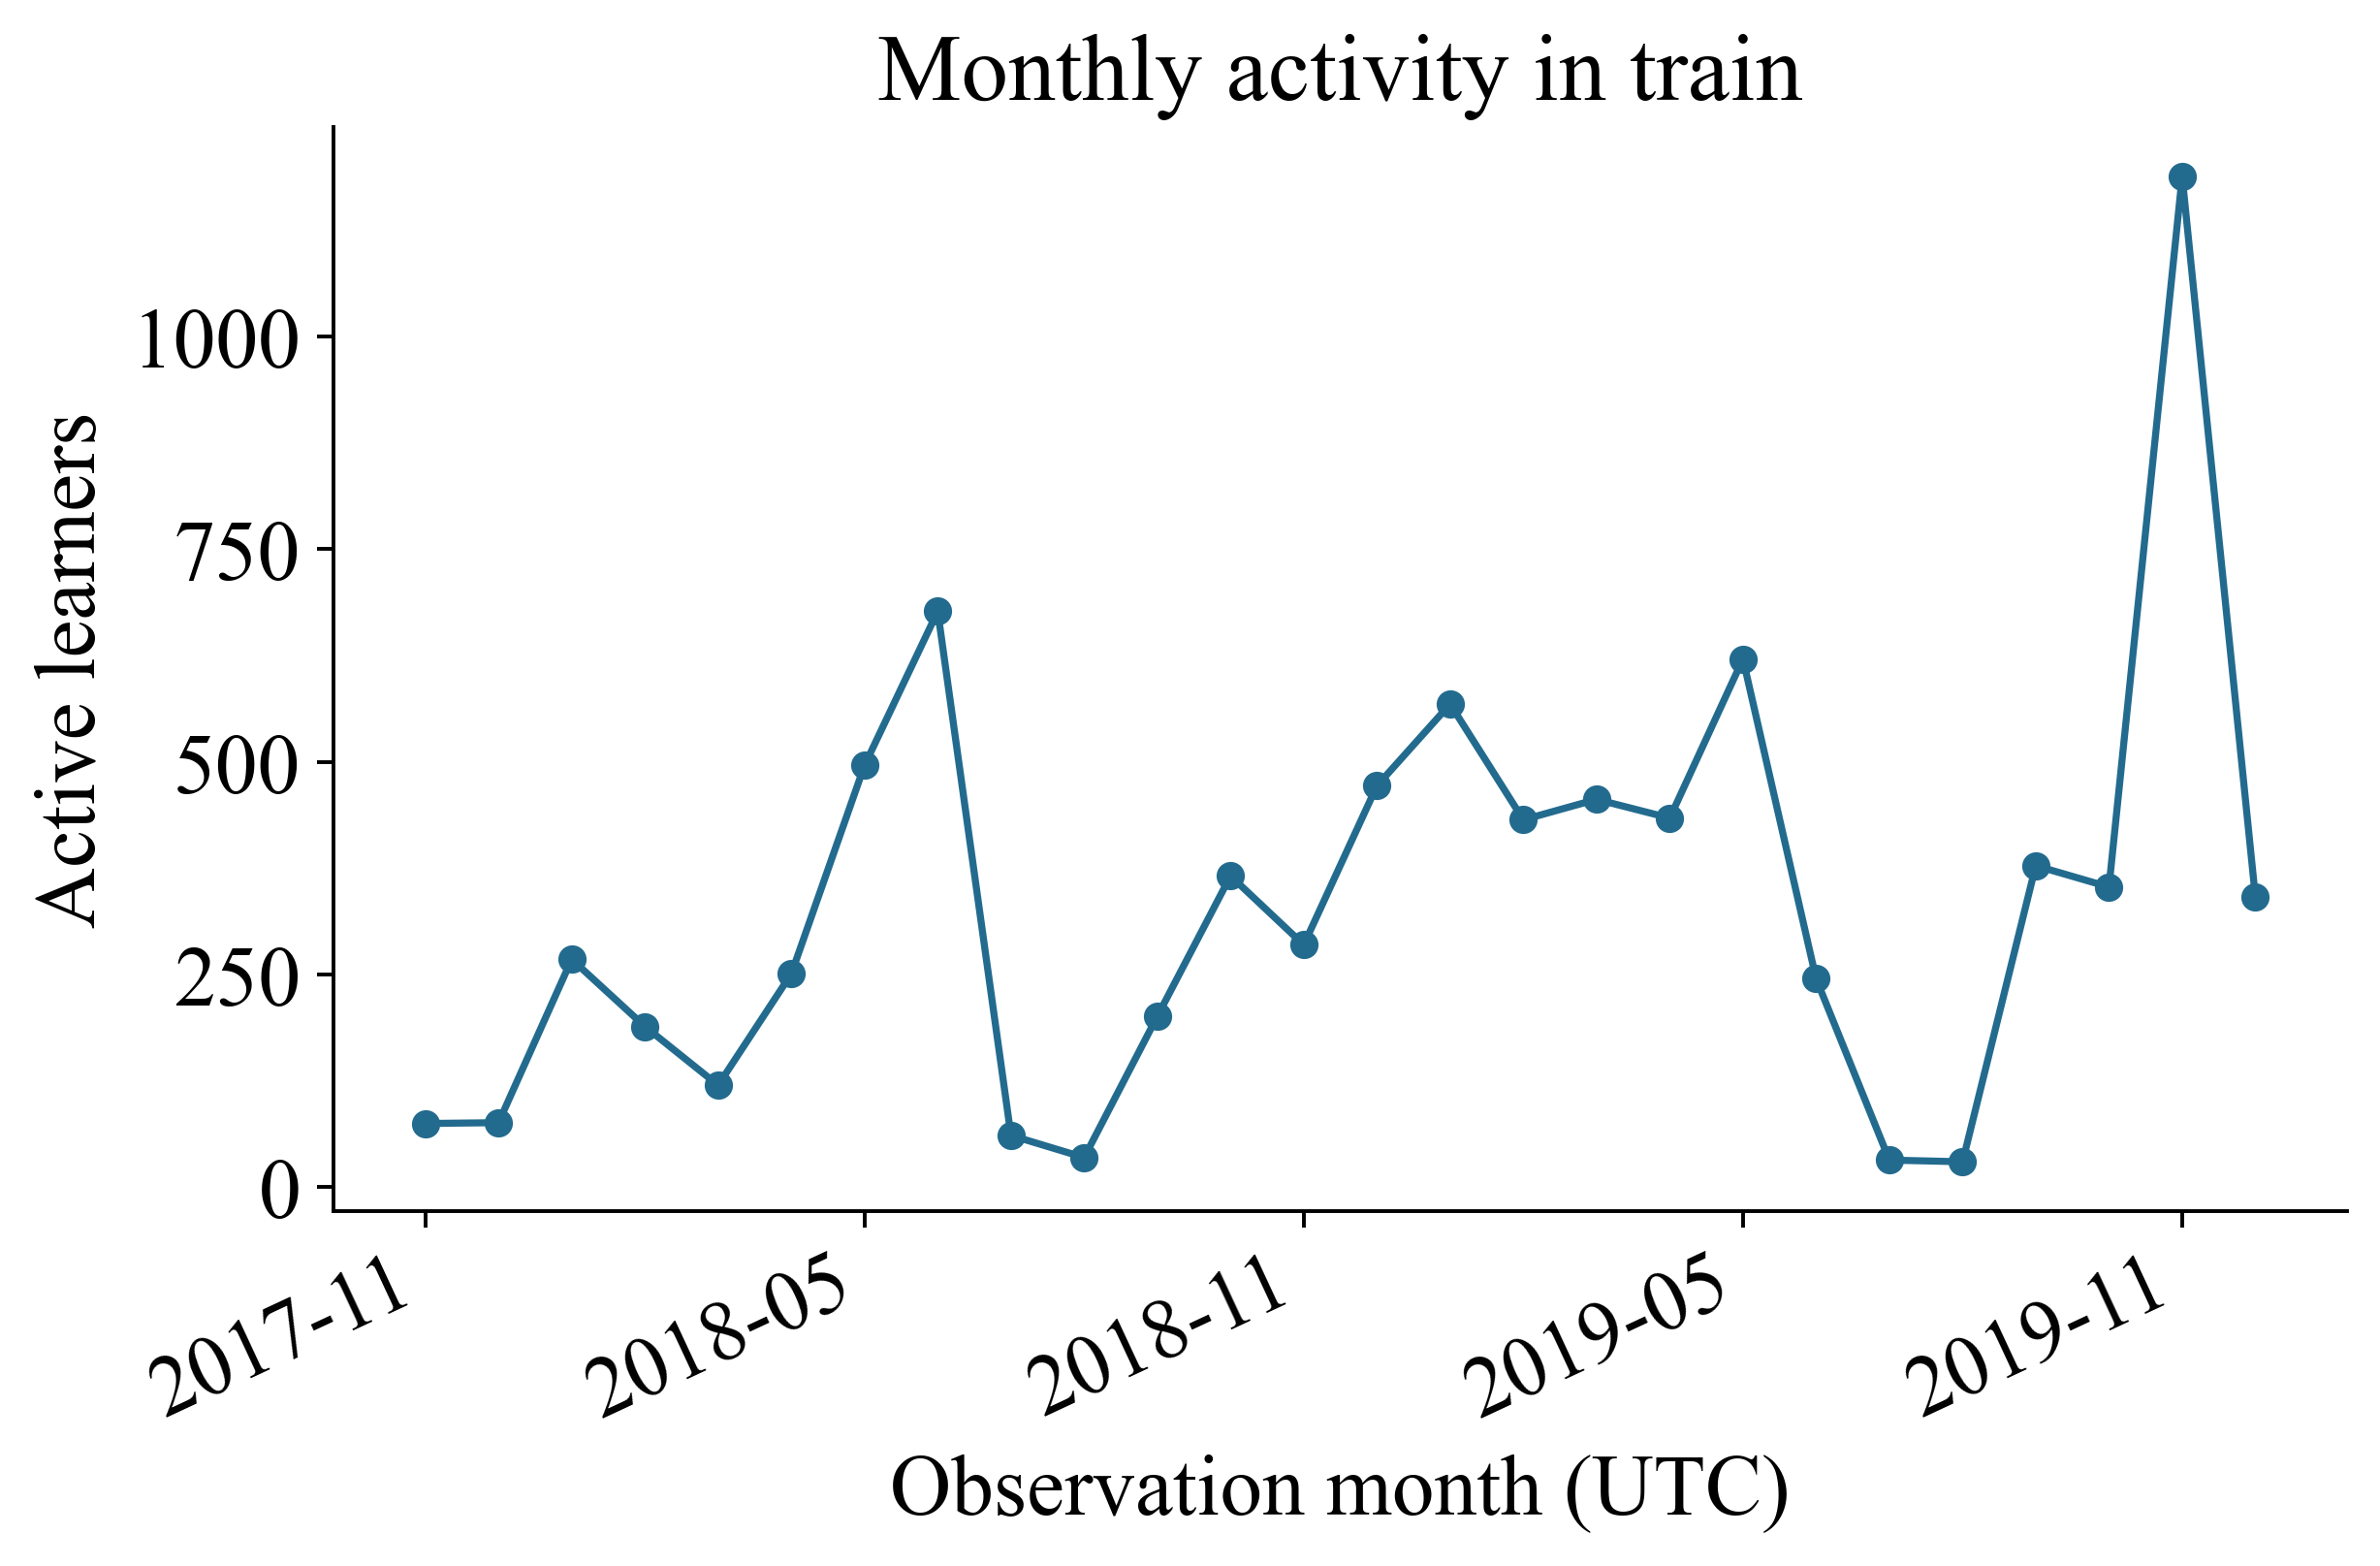

In [12]:
train_events = events[events.student.isin(train_students)]
monthly = (
    train_events.assign(month=train_events.timestamp.dt.strftime("%Y-%m"))
    .groupby("month")
    .agg(active_students=("student", "nunique"), events=("id", "size"))
    .reset_index()
)
monthly.to_csv(ROOT / "artifacts/01_monthly_activity.csv", index=False)
fig, ax = plt.subplots(figsize=(6.9, 4.5), layout="constrained")
x = np.arange(len(monthly))
ax.plot(x, monthly.active_students, color="#236B8E", marker="o", markersize=5)
step = max(1, int(np.ceil(len(monthly) / 5)))
ax.set_xticks(x[::step], monthly.month.iloc[::step], rotation=25, ha="right")
ax.set(
    xlabel="Observation month (UTC)",
    ylabel="Active learners",
    title="Monthly activity in train",
)
ax.spines[["top", "right"]].set_visible(False)
save_figure(fig, "01_monthly_activity")
plt.show()


Активность меняется по месяцам и достигает выраженного пика в конце 2019 года. Неравномерный сбор учитывается при обсуждении обобщения результатов.

## Качество исходных измерений в обучающей части

Выбросы длительности и числа действий описываются, но не удаляются автоматически. Большая длительность может включать перерыв пользователя; её нельзя без дополнительной проверки называть активным временем обучения. Нулевые и пустые программы рассматриваются как реальные состояния интерфейса, если не противоречат схеме.

In [13]:
train_attempts = attempts[attempts.student.isin(train_students)].copy()
quality_rows = []
for col, label in [
    ("time", "Длительность, с"),
    ("n_edits", "Редактирования"),
    ("n_executions", "Запуски"),
]:
    values = train_attempts[col]
    q1, q3 = values.quantile([0.25, 0.75])
    high = q3 + 1.5 * (q3 - q1)
    quality_rows.append(
        [
            label,
            len(values),
            values.isna().sum(),
            values.median(),
            values.quantile(0.95),
            values.max(),
            (values > high).mean(),
        ]
    )
table(
    pd.DataFrame(
        quality_rows,
        columns=[
            "Показатель",
            "n",
            "Пропуски",
            "Медиана",
            "P95",
            "Максимум",
            "Доля выше IQR-границы",
        ],
    ),
    "Таблица 10. Длительность и число действий в train",
    "01_measurement_quality",
)


Таблица 10. Длительность и число действий в train

,Показатель,n,Пропуски,Медиана,P95,Максимум,Доля выше IQR-границы
0,"Длительность, с",115649,0,56.0,546.0,652762,0.109
1,Редактирования,115649,0,7.0,40.0,833,0.081
2,Запуски,115649,0,2.0,12.0,278,0.087


Медиана длительности равна 56 с, а максимум превышает семь суток. Длинные интервалы могут включать паузы; их нельзя автоматически считать временем освоения навыка.

## Доступность исходных школьных признаков

Как часто будущий школьный прогноз будет работать без сведений учителя? Пропуски оцениваются на train. Их индикаторы входят в pipeline; медианы вычисляются только внутри обучающих фолдов. Предварительный балл и итоговая цель не импутируются при формировании основной продольной выборки.

In [14]:
school_train = eligible[eligible.split.eq("train")]
missing_teacher = school_train[teacher_cols].isna()
school_missing = pd.DataFrame(
    [
        [
            "Предварительный балл",
            len(school_train),
            school_train[pre].isna().mean(),
        ],
        [
            "Класс обучения",
            len(school_train),
            school_train["Students' grade"].isna().mean(),
        ],
        [
            "Все 16 сведений учителя отсутствуют",
            len(school_train),
            missing_teacher.all(axis=1).mean(),
        ],
        [
            "Хотя бы одно сведение учителя отсутствует",
            len(school_train),
            missing_teacher.any(axis=1).mean(),
        ],
    ],
    columns=["Показатель", "n", "Доля отсутствия"],
)
table(
    school_missing,
    "Таблица 11. Доступность исходной школьной информации",
    "01_school_missingness",
)


Таблица 11. Доступность исходной школьной информации

,Показатель,n,Доля отсутствия
0,Предварительный балл,909,0.000
1,Класс обучения,909,0.000
2,Все 16 сведений учителя отсутствуют,909,0.149
3,Хотя бы одно сведение учителя отсутствует,909,0.149


Предварительный балл и класс обучения доступны во всех 909 строках train. Сведения учителя отсутствуют совместно приблизительно в 14.9% строк; модель должна поддерживать этот режим.

## Длина наблюдаемой учебной траектории

Какую долю учащихся представляет длительная история? Кривая показывает долю учащихся с не менее чем заданным числом различных посещённых задач. Единица анализа — учащийся train, а не событие; это не повторение таблицы размеров выборки.

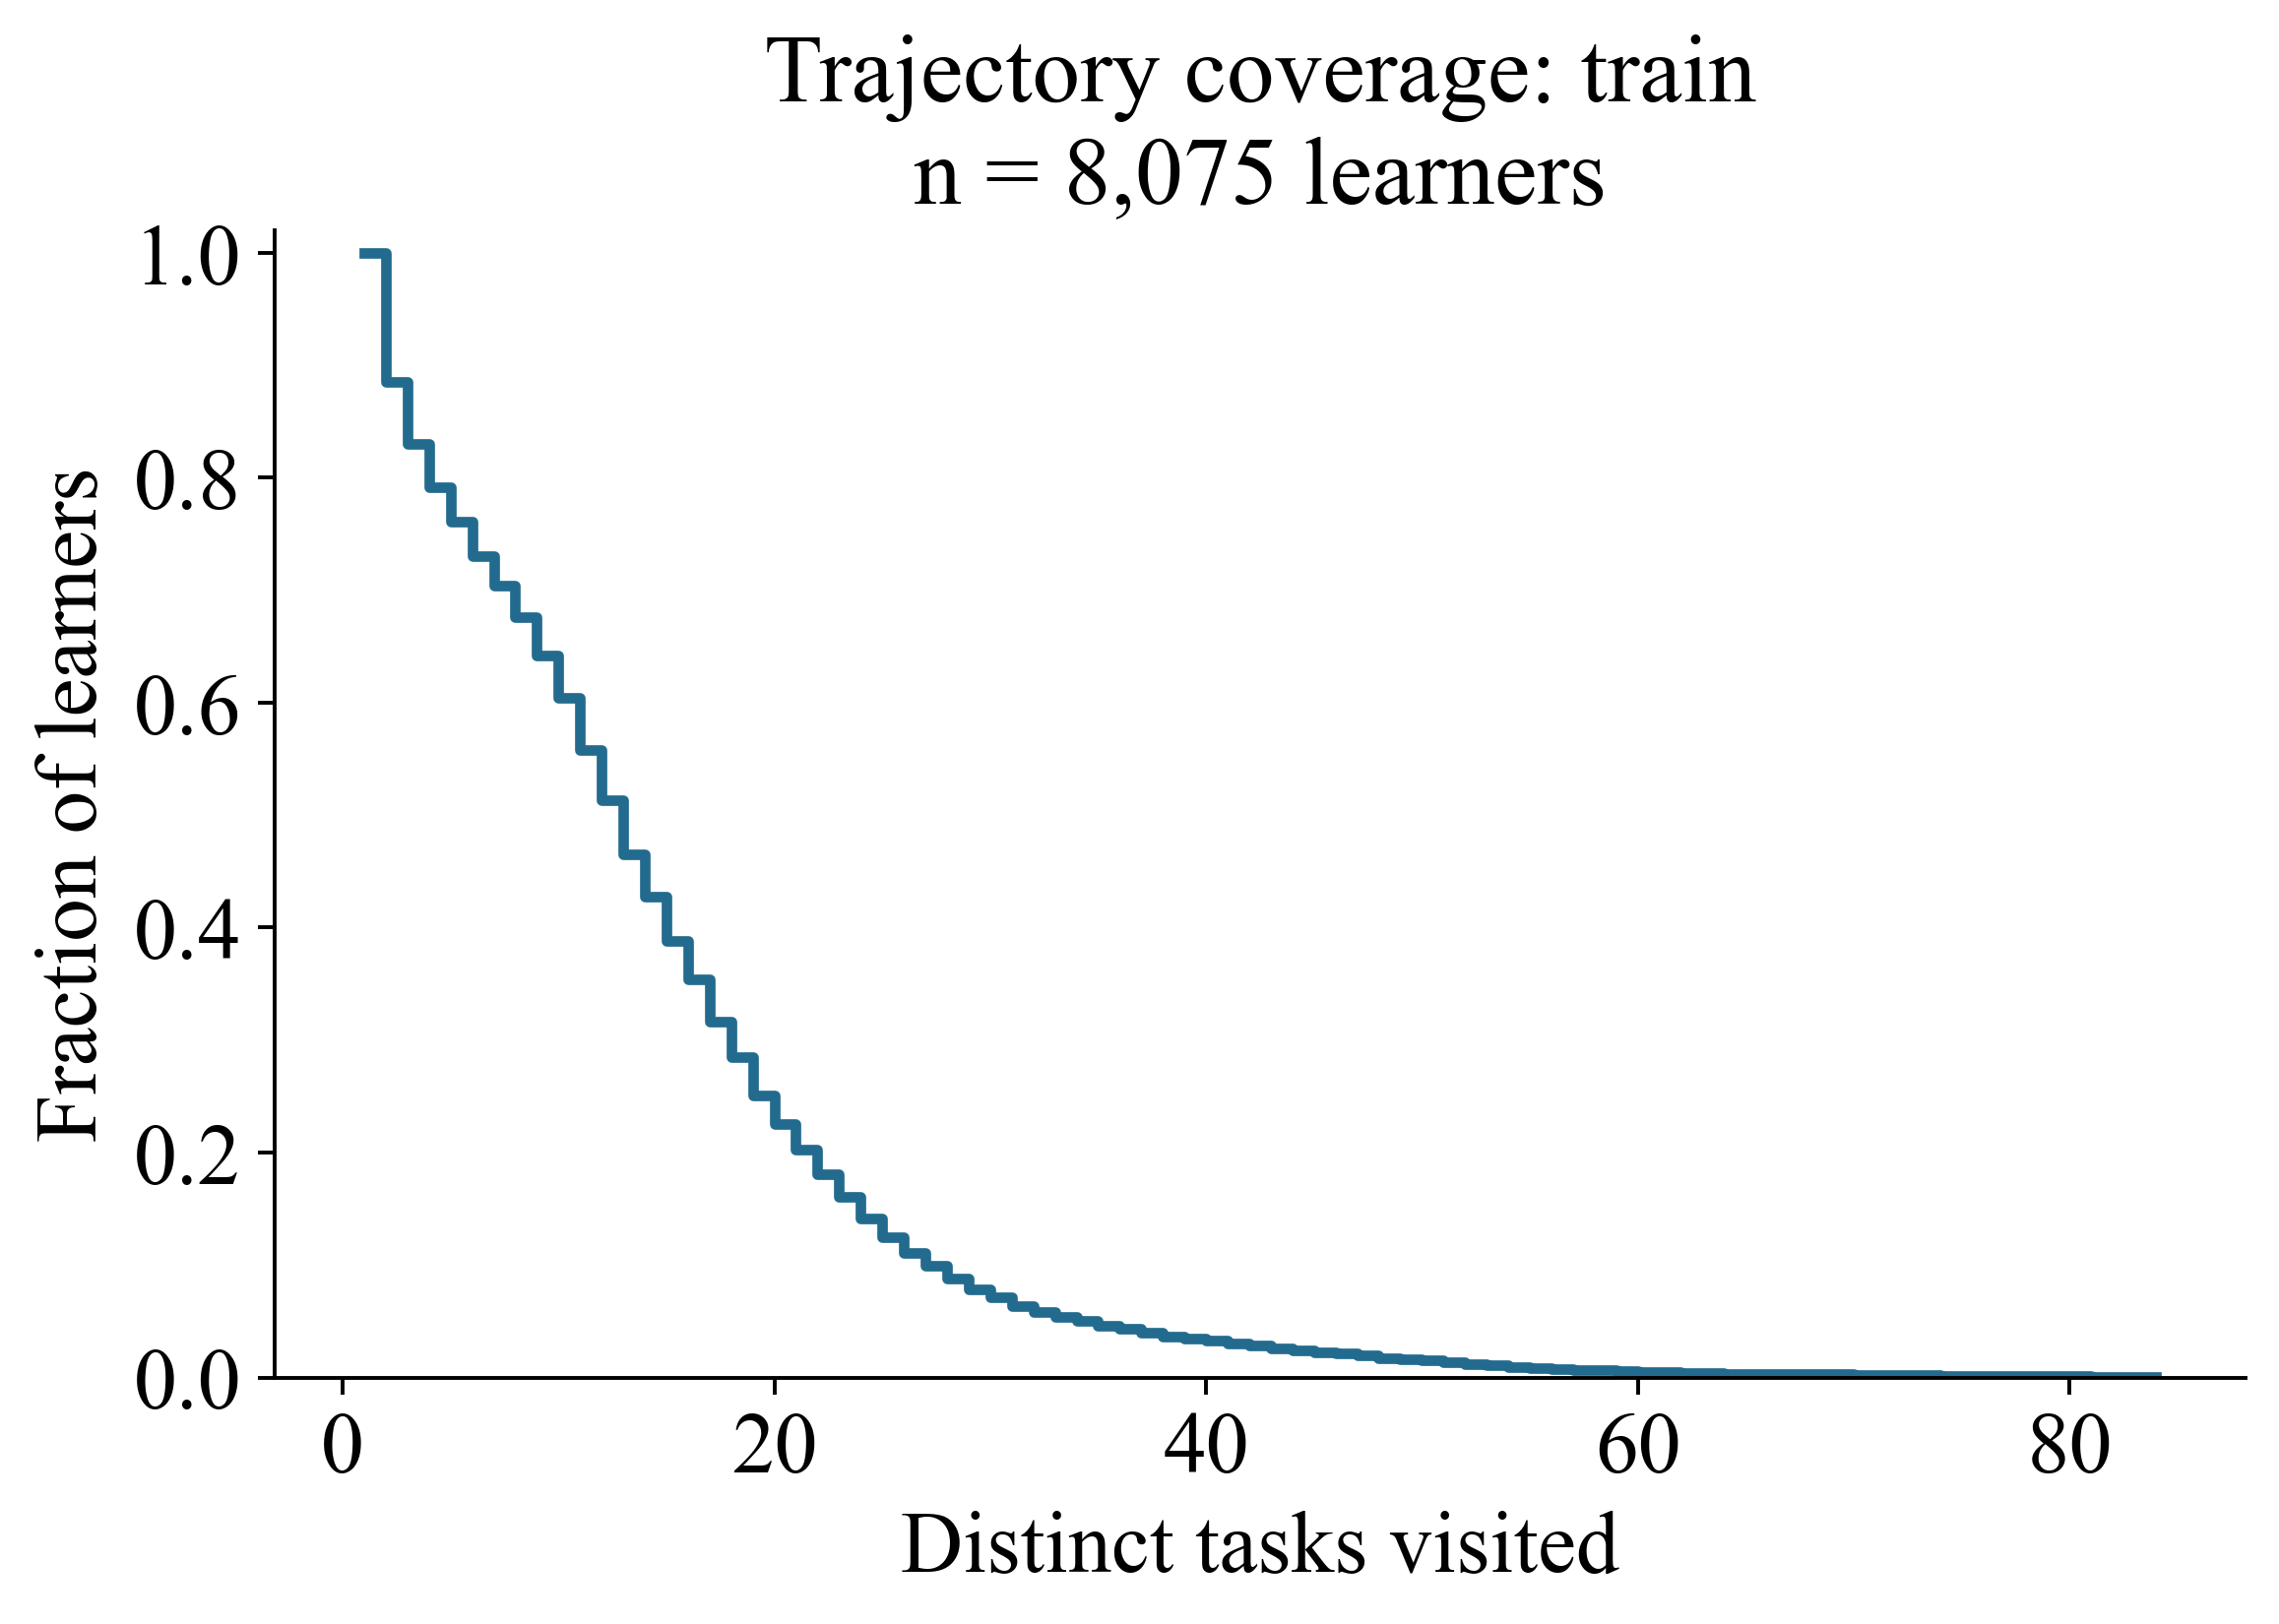

In [15]:
learner_task_counts = train_cohort.groupby("student").problem.nunique()
thresholds = np.arange(1, int(learner_task_counts.max()) + 1)
retained = np.array(
    [(learner_task_counts >= count).mean() for count in thresholds]
)
pd.DataFrame(
    {"minimum_tasks": thresholds, "fraction_learners": retained}
).to_csv(ROOT / "artifacts/01_trajectory_length.csv", index=False)
fig, ax = plt.subplots(figsize=(6.5, 4.6), layout="constrained")
ax.step(thresholds, retained, where="post", color="#236B8E", linewidth=2.2)
ax.set(
    xlabel="Distinct tasks visited",
    ylabel="Fraction of learners",
    ylim=(0, 1.02),
    title=f"Trajectory coverage: train\nn = {len(learner_task_counts):,} learners",
)
ax.spines[["top", "right"]].set_visible(False)
save_figure(fig, "01_trajectory_length")
plt.show()


Доля учащихся быстро уменьшается с увеличением числа посещённых заданий. Длинный контекст доступен лишь небольшой части выборки; режим короткой истории должен оцениваться отдельно.

## Концентрация наблюдений по заданиям

Равномерно ли архив покрывает задания? Накопленная кривая ранжирует задания по числу первых посещений. Диагональ обозначает равномерное покрытие; отклонение характеризует концентрацию, а не качество модели.

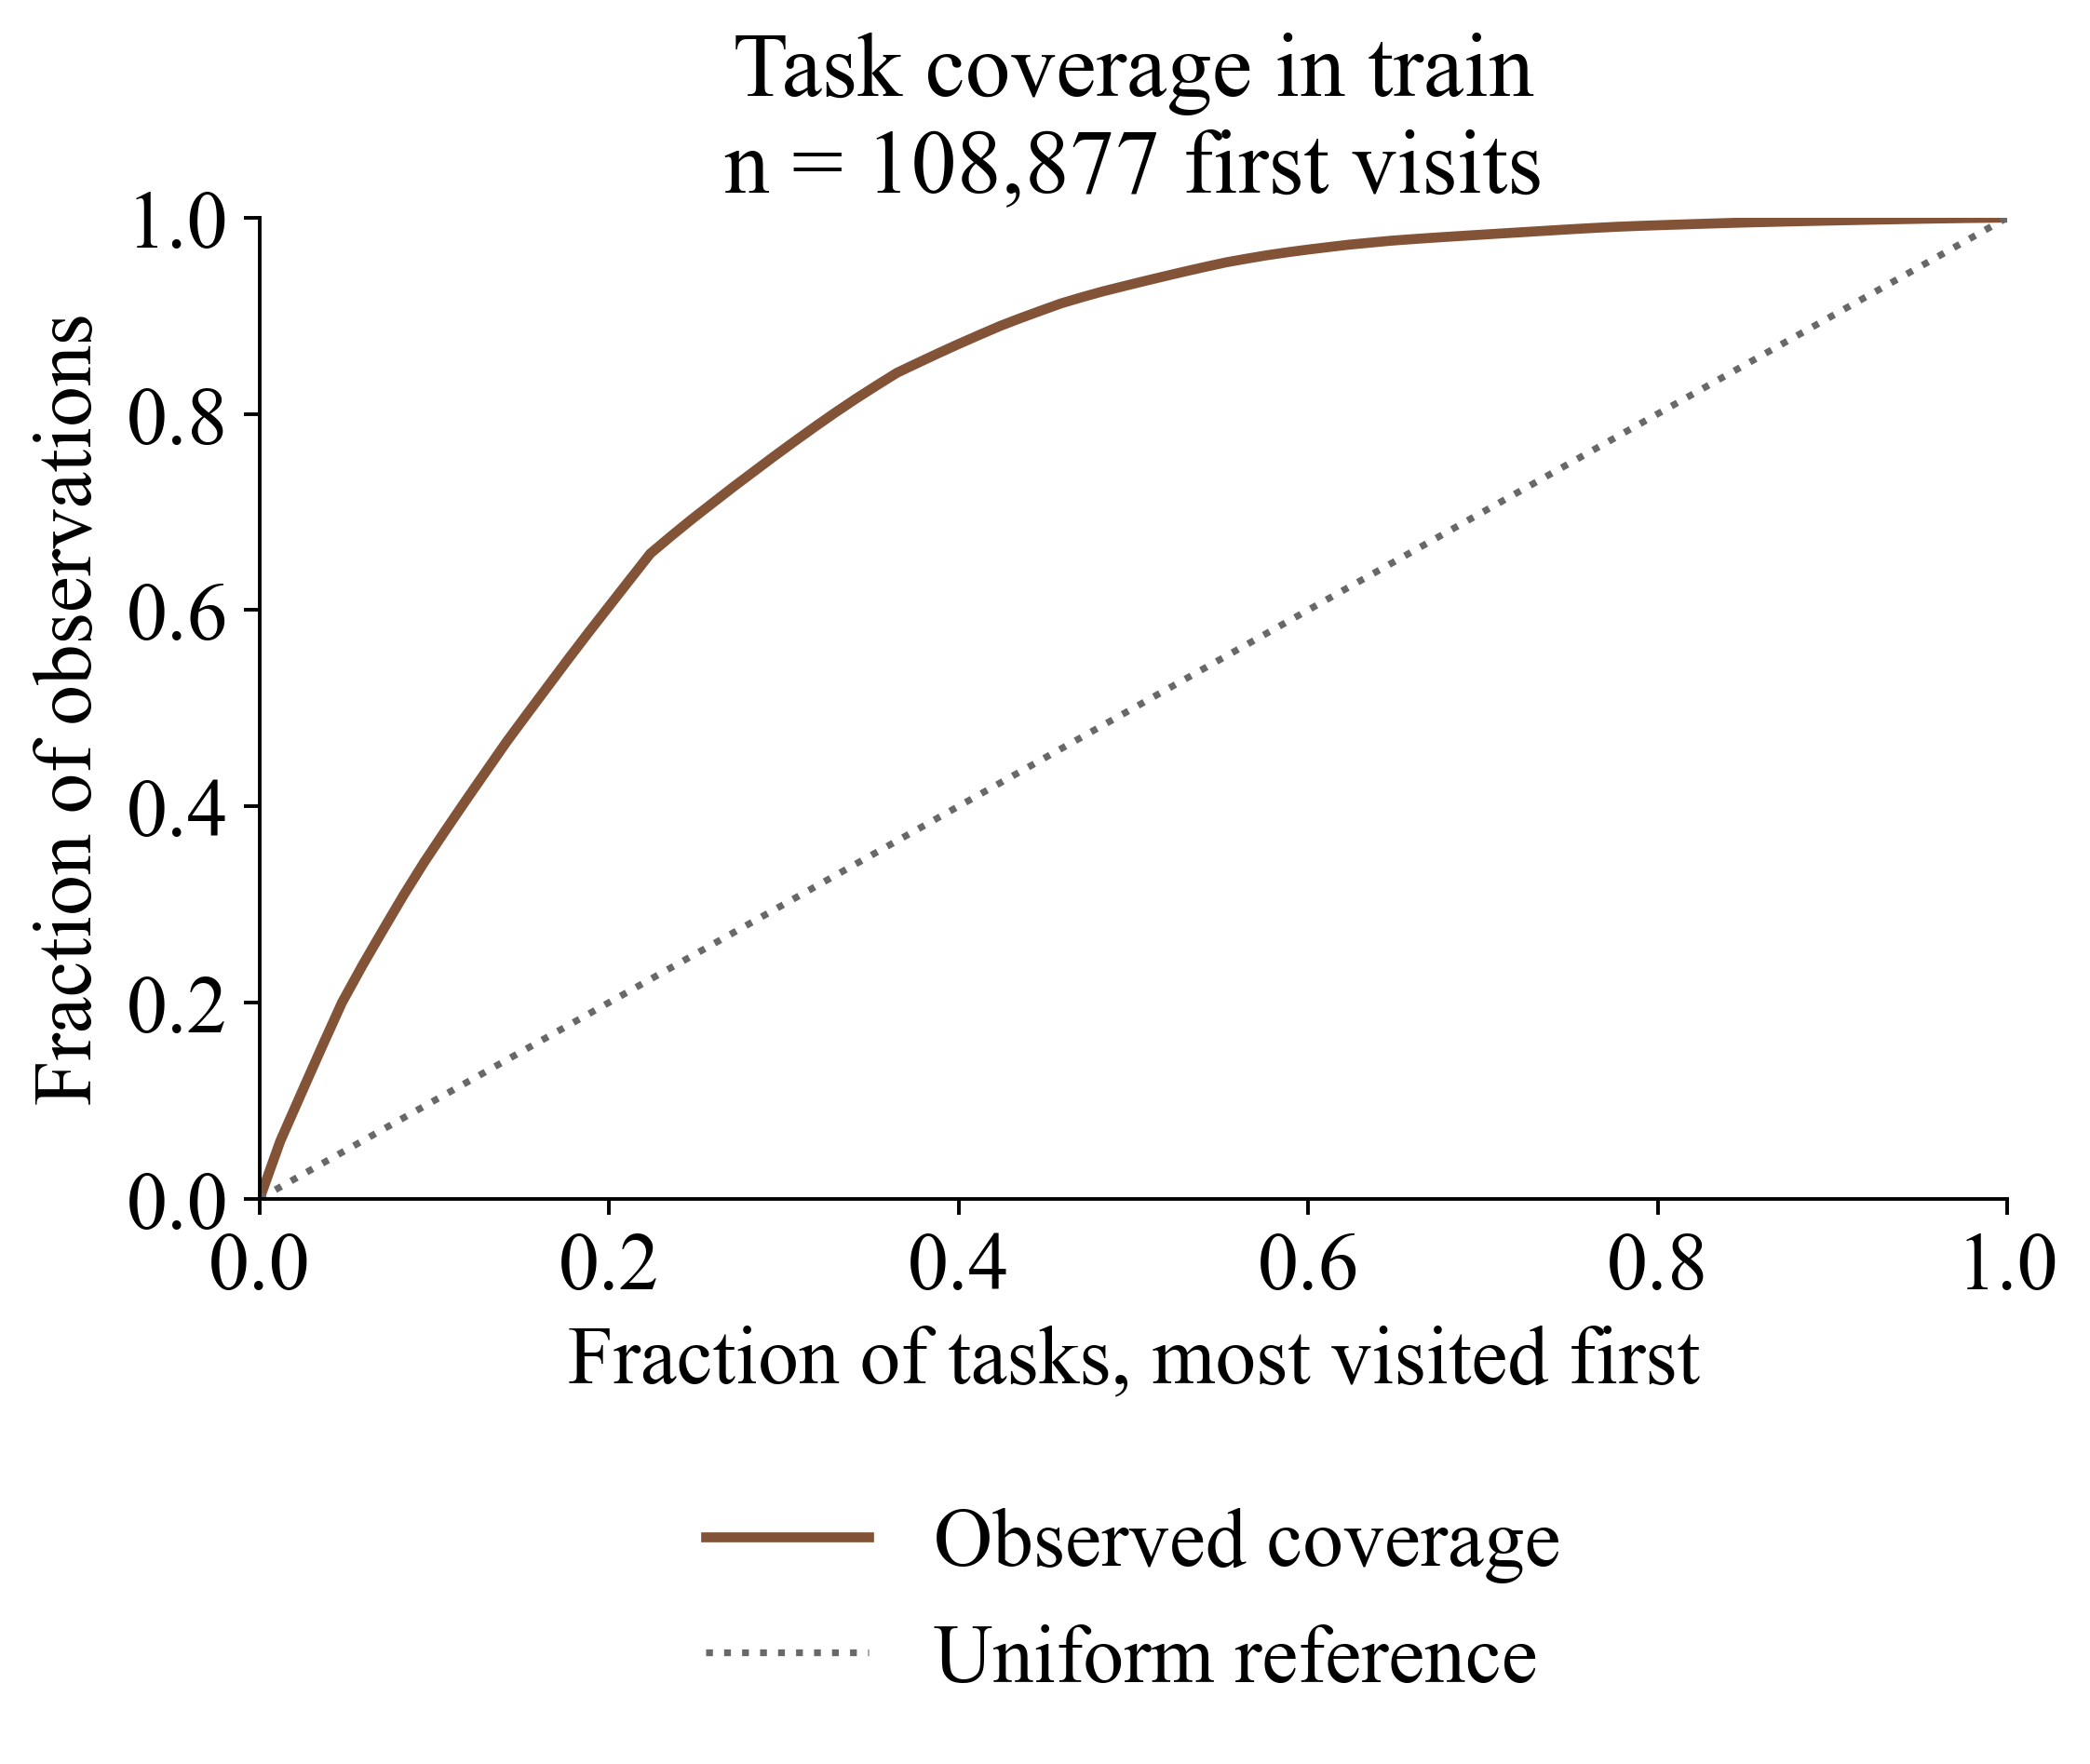

In [16]:
task_exposure = (
    train_cohort.groupby("problem").size().sort_values(ascending=False)
)
exposure_fraction = task_exposure.cumsum().to_numpy() / task_exposure.sum()
task_fraction = np.arange(1, len(task_exposure) + 1) / len(task_exposure)
pd.DataFrame(
    {
        "problem": task_exposure.index,
        "n": task_exposure.to_numpy(),
        "task_fraction": task_fraction,
        "observation_fraction": exposure_fraction,
    }
).to_csv(ROOT / "artifacts/01_task_concentration.csv", index=False)
fig, ax = plt.subplots(figsize=(6.3, 5.3), layout="constrained")
ax.plot(
    np.r_[0, task_fraction],
    np.r_[0, exposure_fraction],
    color="#825337",
    linewidth=2.2,
    label="Observed coverage",
)
ax.plot(
    [0, 1], [0, 1], color="#686868", linestyle=":", label="Uniform reference"
)
ax.set(
    xlabel="Fraction of tasks, most visited first",
    ylabel="Fraction of observations",
    title=f"Task coverage in train\nn = {len(train_cohort):,} first visits",
    xlim=(0, 1),
    ylim=(0, 1),
)
ax.legend(
    loc="upper center", bbox_to_anchor=(0.5, -0.24), frameon=False, ncol=1
)
ax.spines[["top", "right"]].set_visible(False)
save_figure(fig, "01_task_concentration")
plt.show()


Кривая существенно выше равномерной диагонали: небольшая доля заданий аккумулирует большую долю посещений. Средняя метрика поэтому сильнее отражает часто посещаемые задачи; полезны отдельные результаты по заданиям и разделам.

## Длительность и редактирование: совместная структура

Сопровождаются ли длительные эпизоды большим числом изменений программы? Логарифмические оси сохраняют все наблюдения и позволяют увидеть плотность без удаления хвостов. Длительность не интерпретируется как время непрерывной работы.

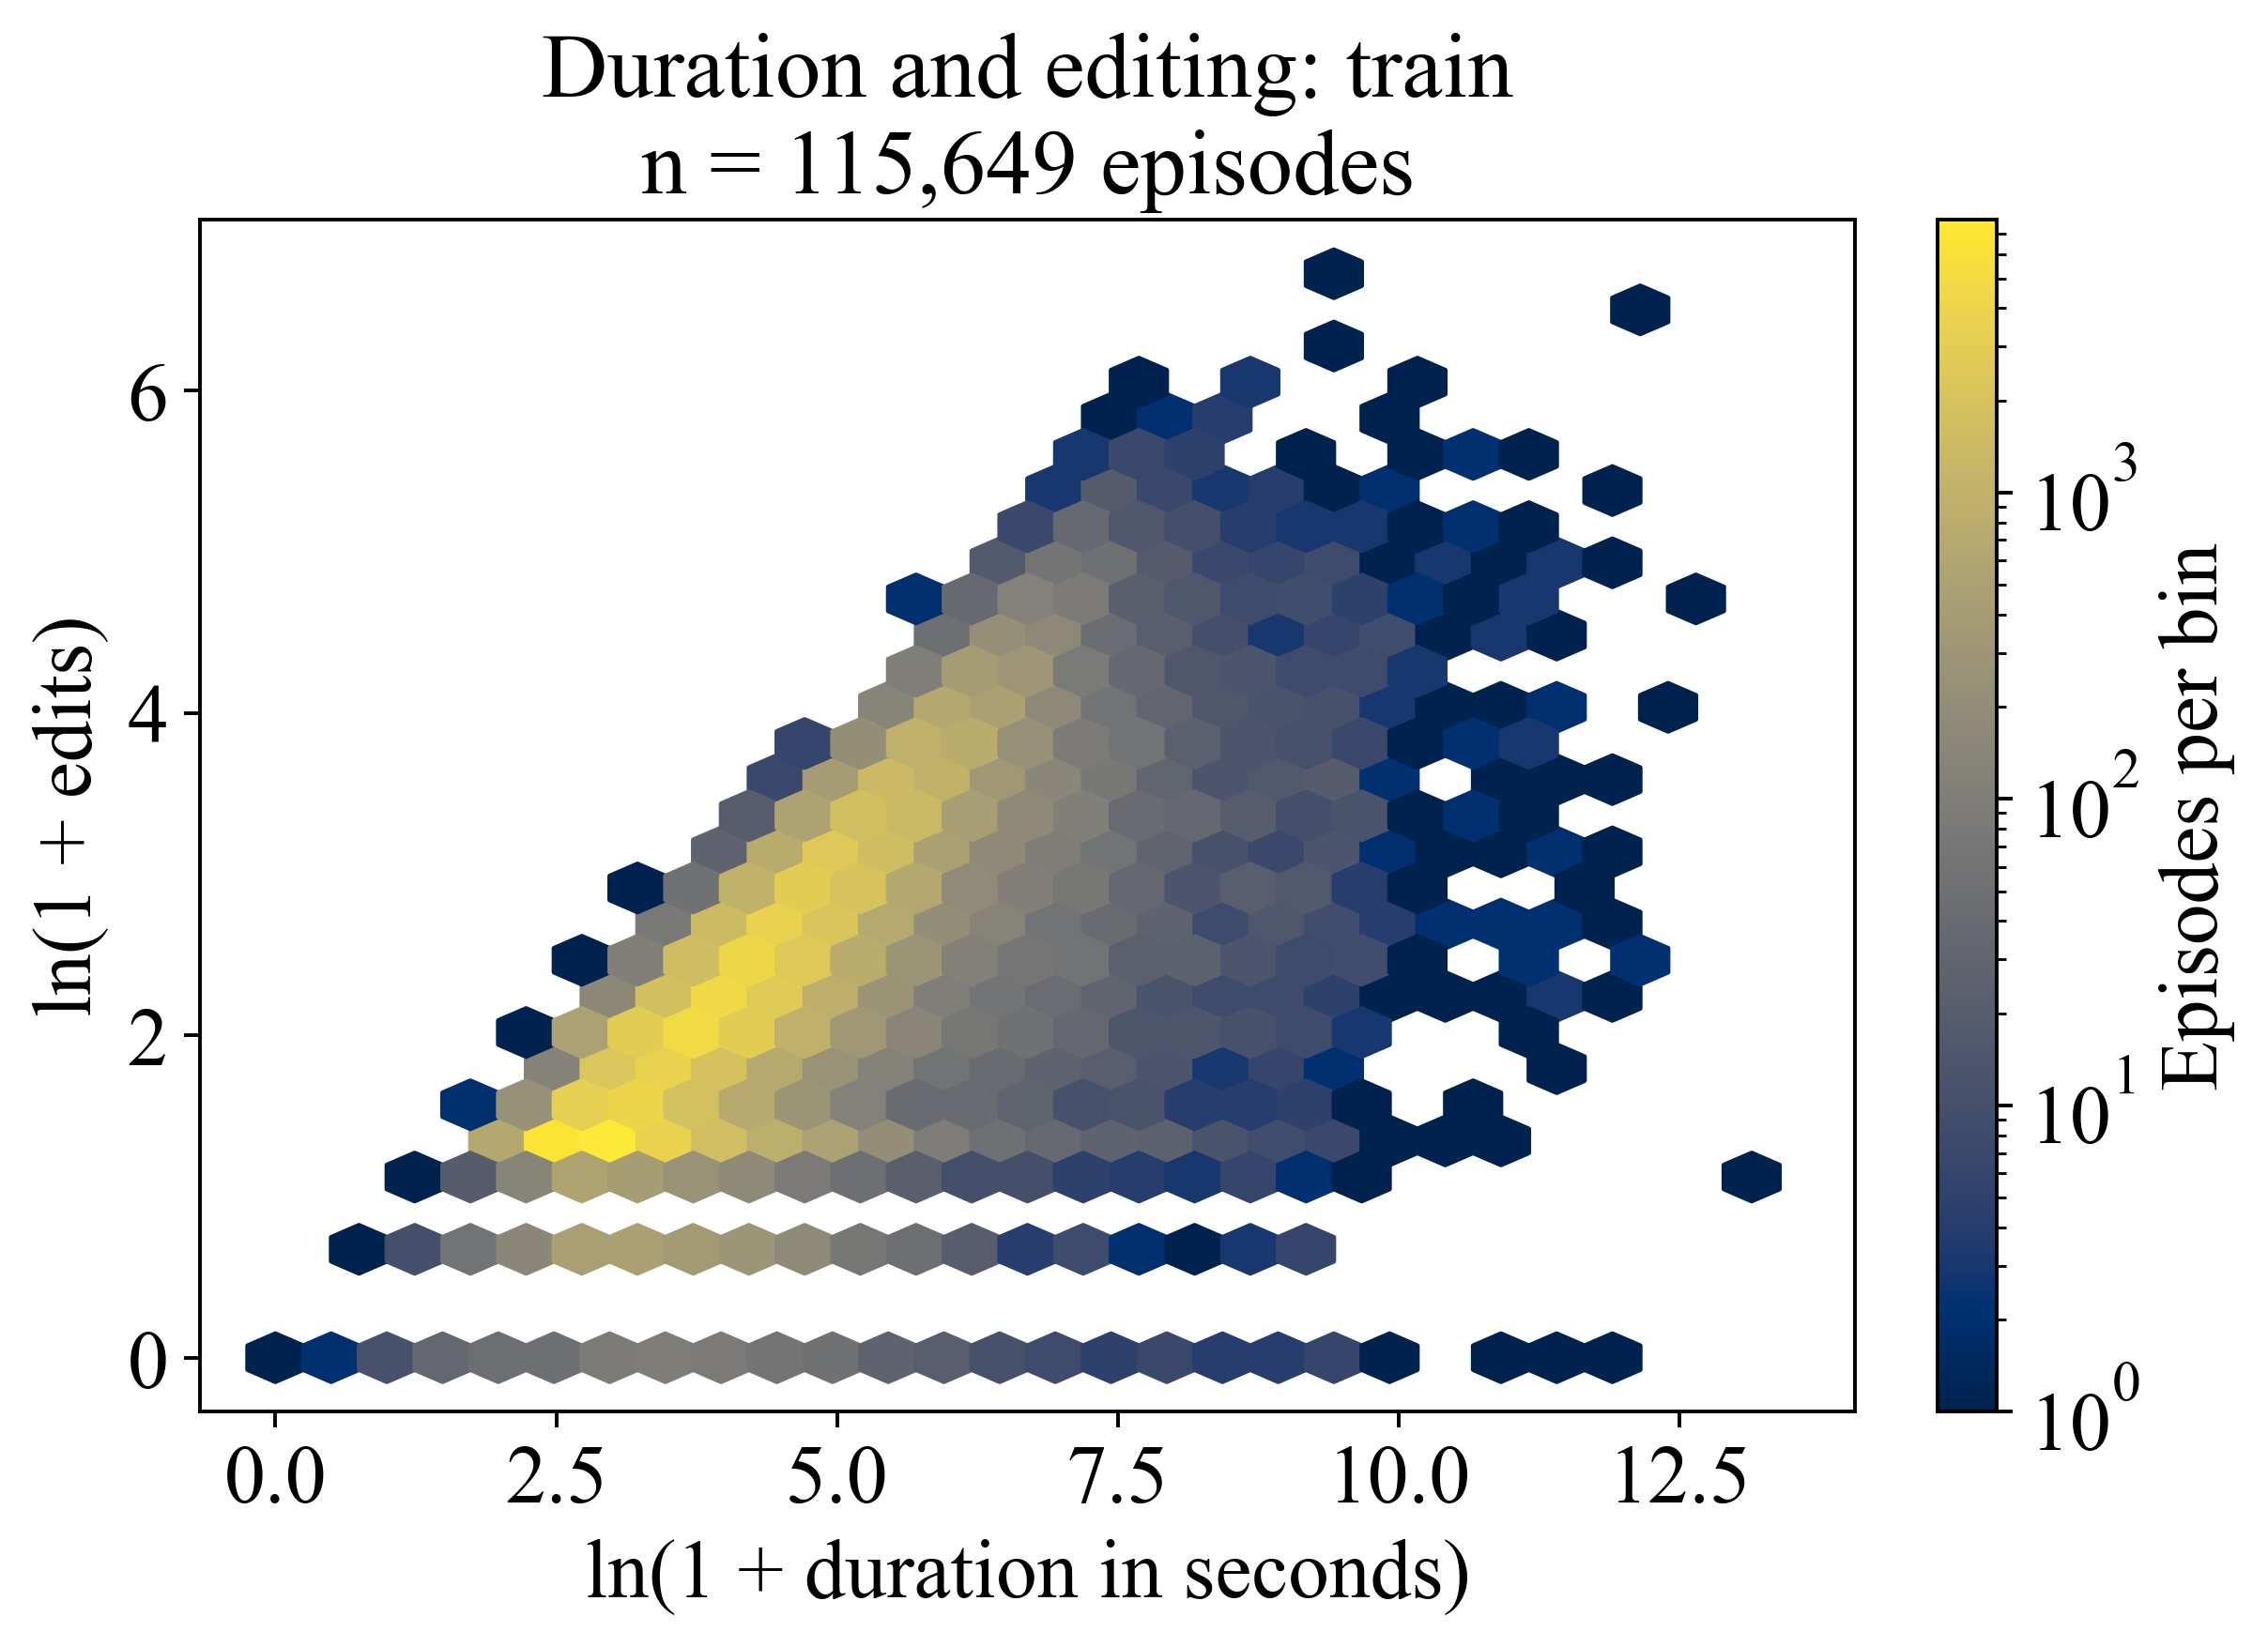

In [17]:
from matplotlib.colors import LogNorm

joint_duration = train_attempts[["time", "n_edits"]].copy()
assert joint_duration.ge(0).all().all()
joint_duration.to_csv(
    ROOT / "artifacts/01_duration_edit_source.csv", index=False
)
fig, ax = plt.subplots(figsize=(6.8, 4.9), layout="constrained")
artist = ax.hexbin(
    np.log1p(joint_duration.time),
    np.log1p(joint_duration.n_edits),
    gridsize=27,
    mincnt=1,
    norm=LogNorm(),
    cmap="cividis",
)
ax.set(
    xlabel="ln(1 + duration in seconds)",
    ylabel="ln(1 + edits)",
    title=f"Duration and editing: train\nn = {len(joint_duration):,} episodes",
)
fig.colorbar(artist, ax=ax, label="Episodes per bin")
save_figure(fig, "01_duration_edit_density")
plt.show()


Основная плотность возрастает совместно по длительности и числу редактирований, но встречаются очень долгие эпизоды с небольшим числом действий. Длительность содержит информацию о паузах и не заменяет прямую меру учебного усилия.

## Согласованность начального и итогового школьного результата

Как связаны два измерения cCTt в независимой школьной ветви? Плотность пар строится только по train. Диагональ означает равенство баллов. Расположение выше диагонали само по себе не доказывает эффект образовательного вмешательства: контрольного сравнения здесь нет.

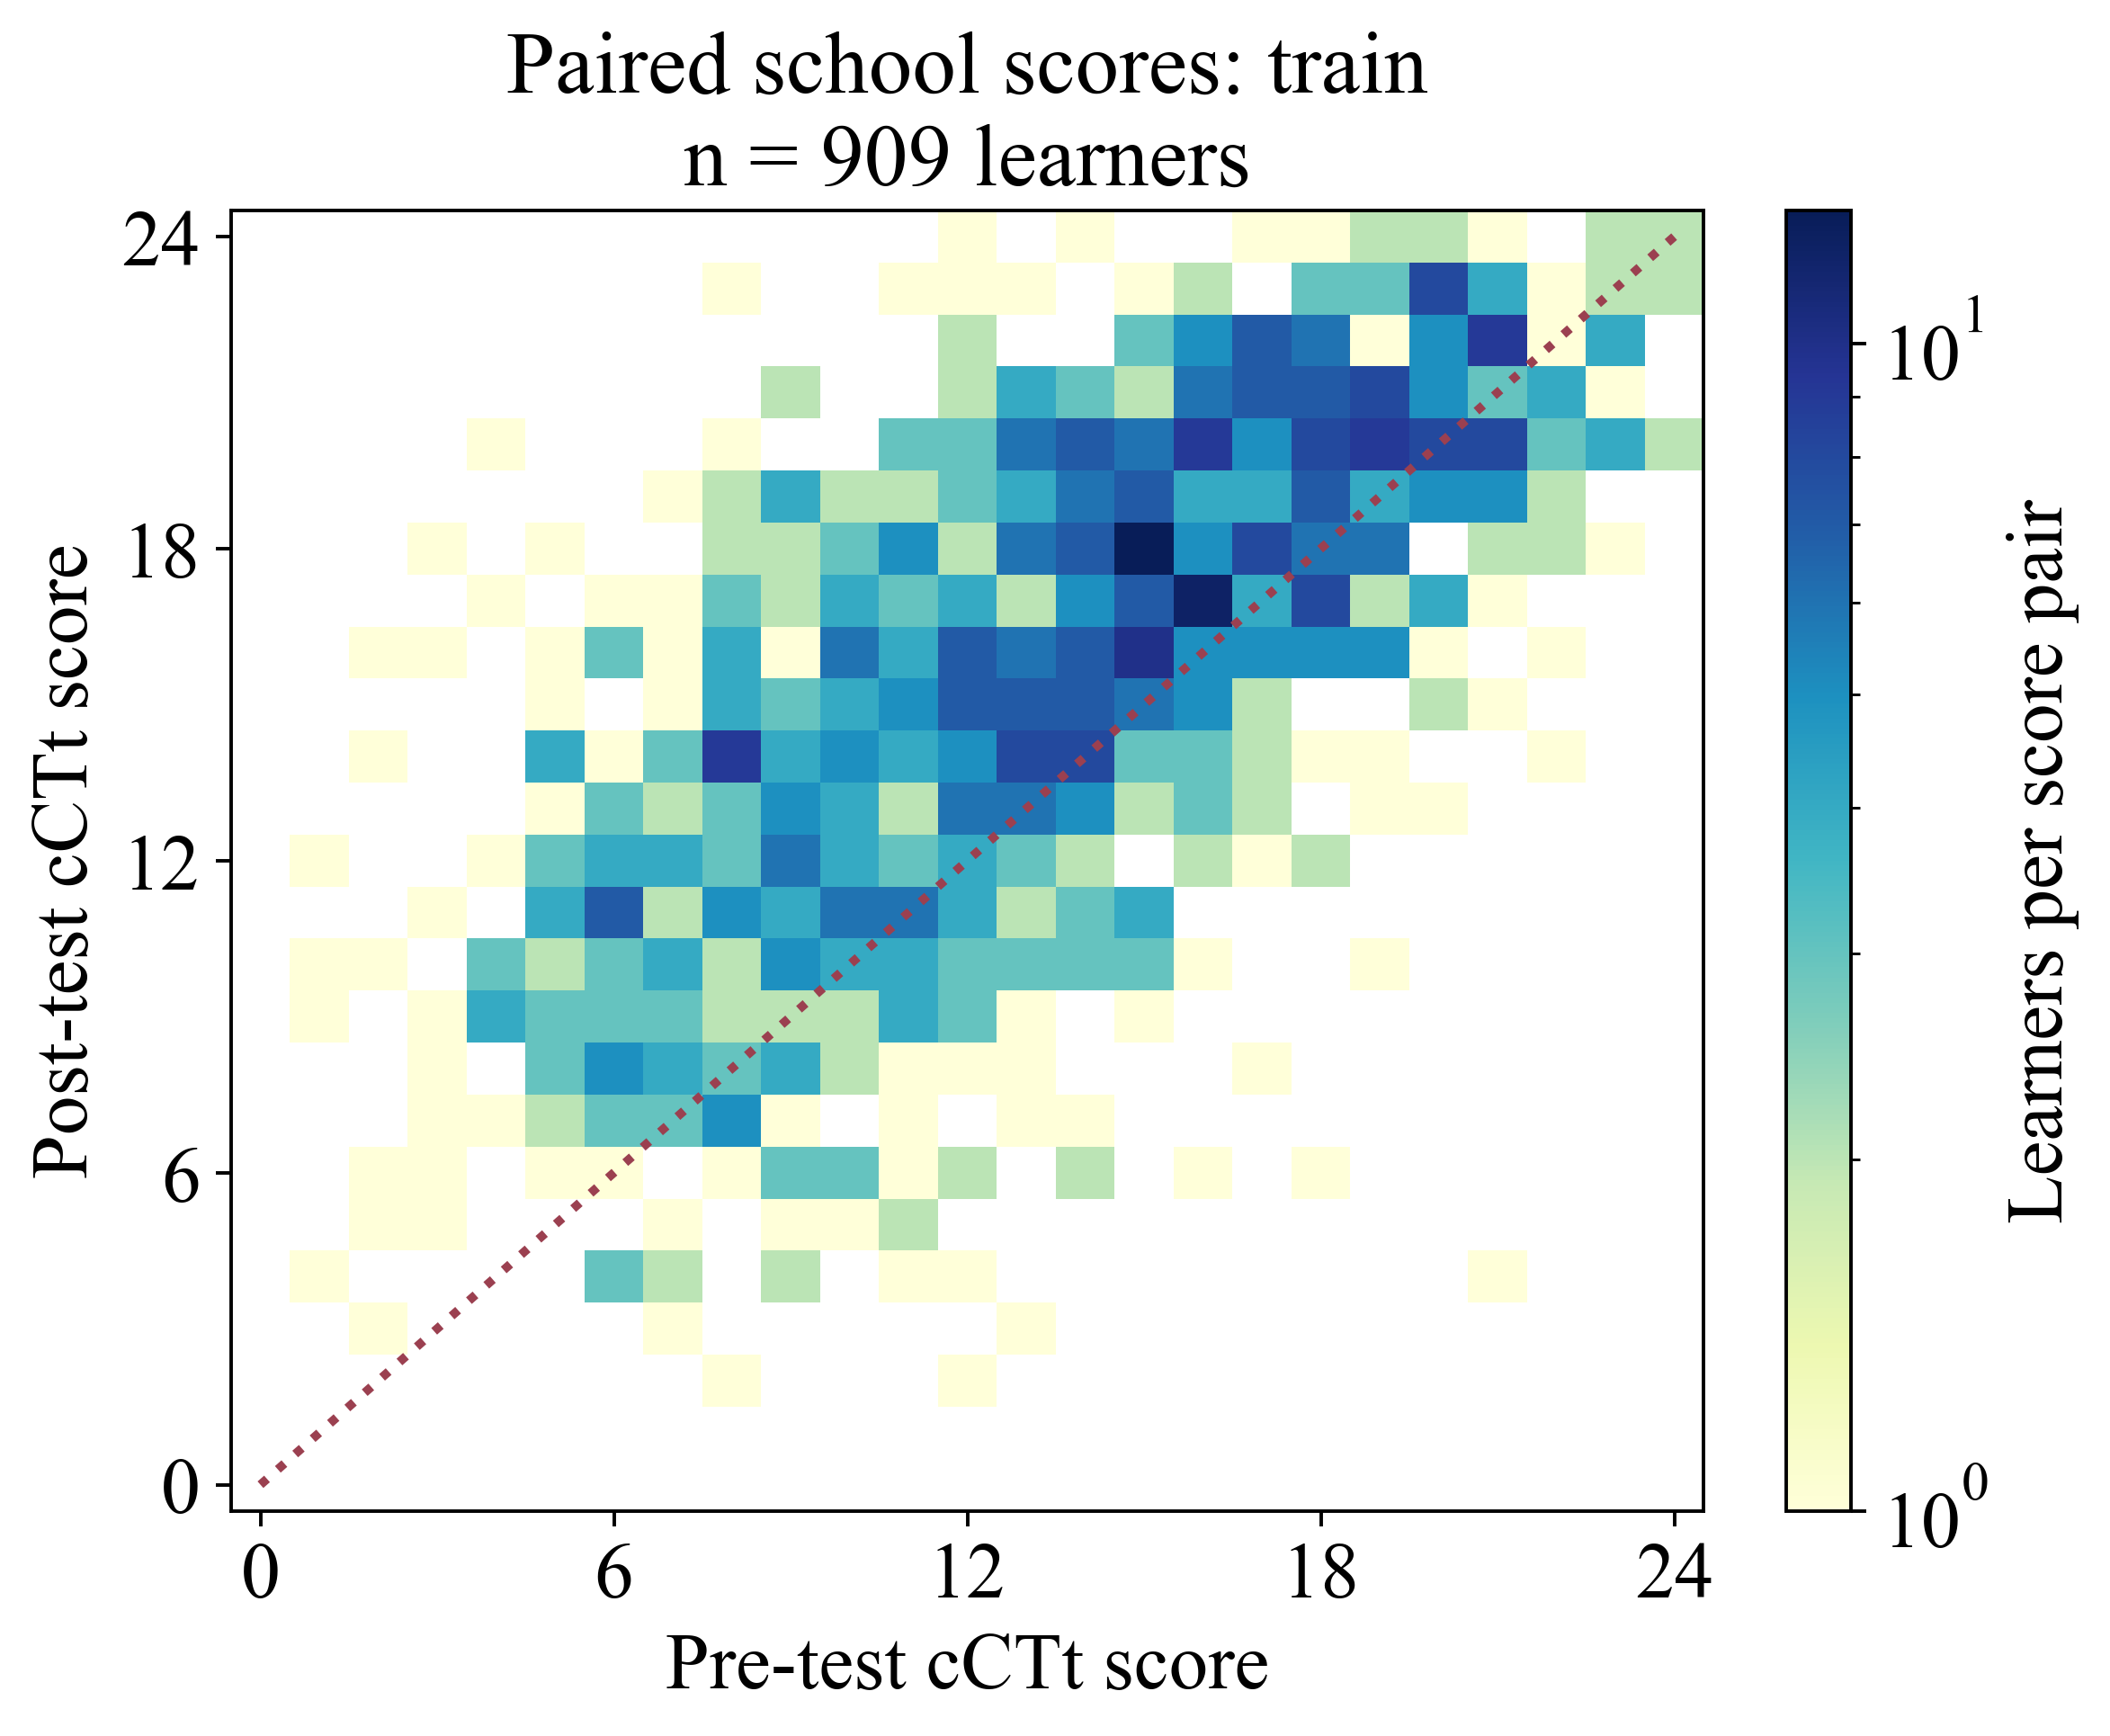

In [18]:
school_pairs = school_train[[pre, post]].copy()
school_pairs.to_csv(
    ROOT / "artifacts/01_school_paired_scores.csv", index=False
)
fig, ax = plt.subplots(figsize=(6.6, 5.4), layout="constrained")
artist = ax.hist2d(
    school_pairs[pre],
    school_pairs[post],
    bins=[np.arange(-0.5, 25, 0.999999), np.arange(-0.5, 25, 0.999999)],
    norm=LogNorm(),
    cmap="YlGnBu",
    cmin=1,
)[3]
ax.plot([0, 24], [0, 24], color="#9B4050", linestyle=":", linewidth=2)
ax.set(
    xlabel="Pre-test cCTt score",
    ylabel="Post-test cCTt score",
    xlim=(-0.5, 24.5),
    ylim=(-0.5, 24.5),
    xticks=[0, 6, 12, 18, 24],
    yticks=[0, 6, 12, 18, 24],
    title=f"Paired school scores: train\nn = {len(school_pairs):,} learners",
)
fig.colorbar(artist, ax=ax, label="Learners per score pair")
save_figure(fig, "01_school_score_density")
plt.show()


Начальный и итоговый баллы демонстрируют положительную зависимость. Плотность пар заметна по обе стороны диагонали; предварительный балл является необходимым ориентиром для будущего регрессионного сравнения.

## Временная граница доступной информации

Что разрешено использовать при прогнозе? Схема фиксирует исследовательский дизайн, а не измеренный эффект: используются только события, наблюдённые строго до начала нового задания. Прошлая попытка может продолжаться после момента прогноза; доступен только её уже наблюдённый префикс. События текущего задания и будущие продолжения исключены из входов.

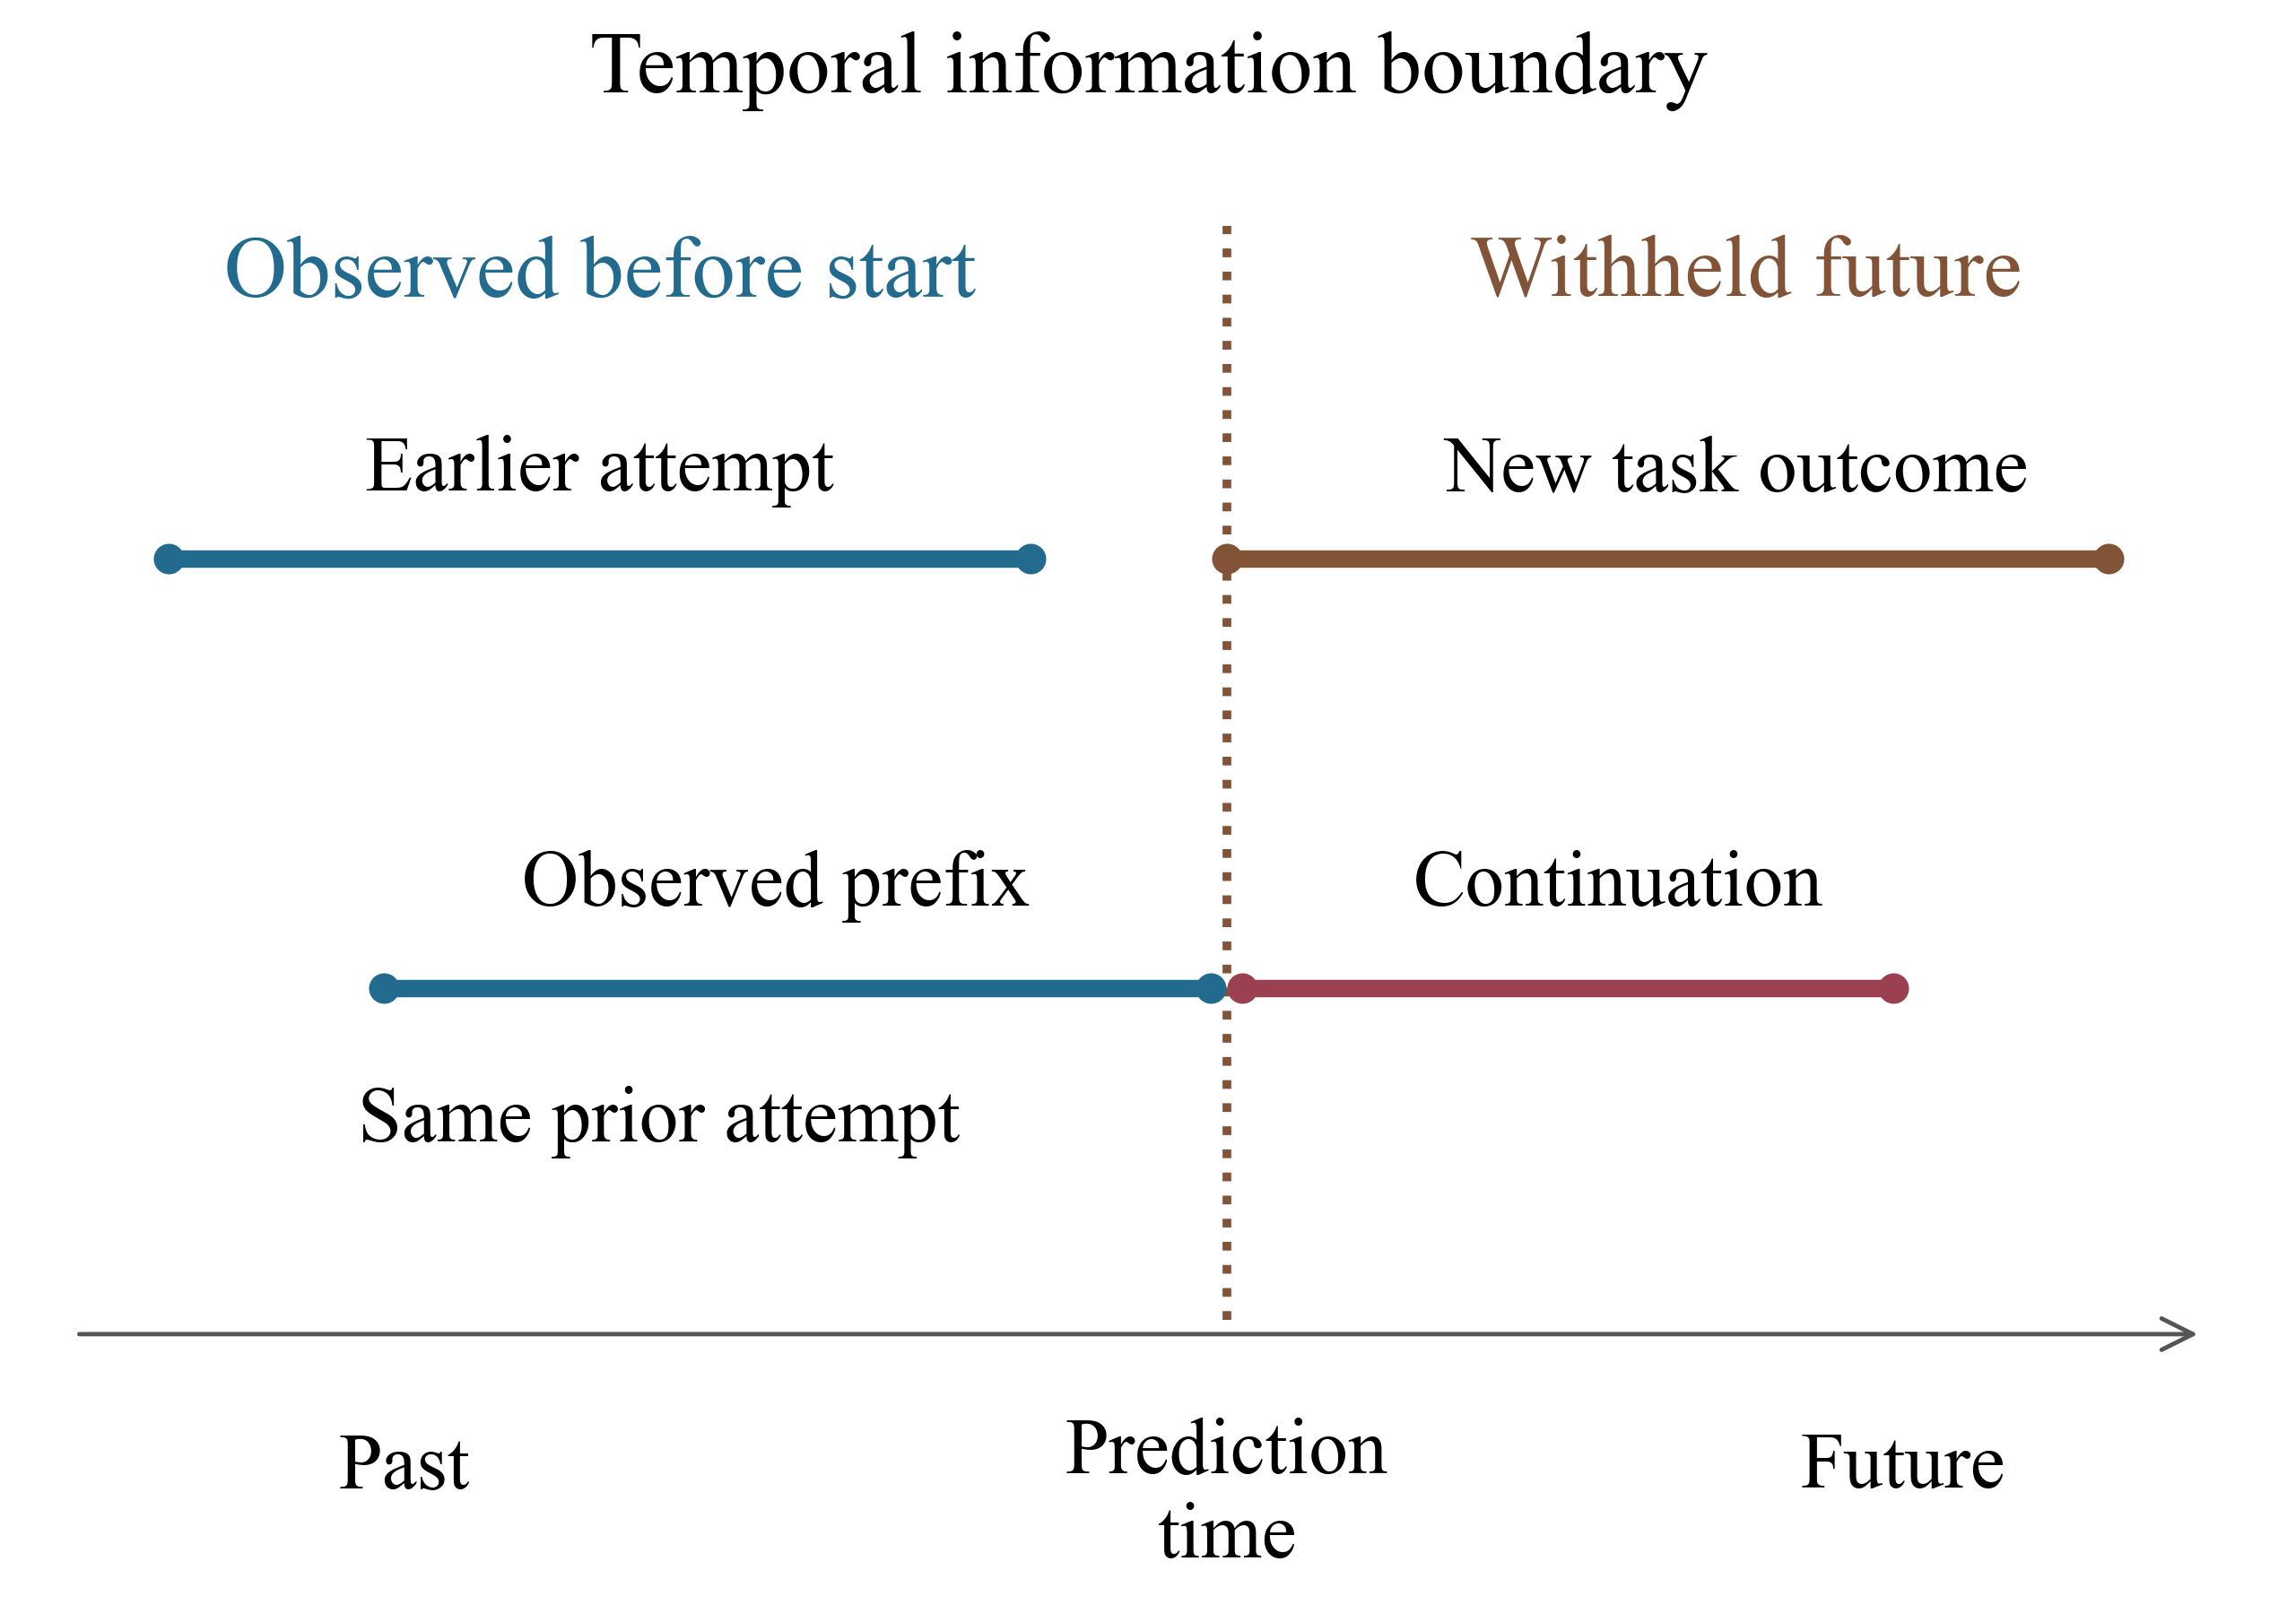

In [19]:
fig, ax = plt.subplots(figsize=(7.2, 5.0), layout="constrained")
ax.set_xlim(-6.1, 5.3)
ax.set_ylim(-1.2, 3.9)
ax.axis("off")
ax.plot([0, 0], [-0.3, 3.65], color="#825337", linestyle=":", linewidth=2)
ax.annotate(
    "",
    xy=(5.0, -0.35),
    xytext=(-5.9, -0.35),
    arrowprops={"arrowstyle": "->", "color": "#555555"},
)
ax.text(
    -3.2,
    3.4,
    "Observed before start",
    ha="center",
    fontsize=20,
    color="#236B8E",
)
ax.text(
    2.65, 3.4, "Withheld future", ha="center", fontsize=20, color="#825337"
)
ax.plot([-5.4, -1.0], [2.45, 2.45], color="#236B8E", linewidth=4, marker="o")
ax.text(-3.2, 2.7, "Earlier attempt", ha="center", fontsize=18)
ax.plot([0, 4.5], [2.45, 2.45], color="#825337", linewidth=4, marker="o")
ax.text(2.6, 2.7, "New task outcome", ha="center", fontsize=18)
ax.plot([-4.3, -0.08], [0.9, 0.9], color="#236B8E", linewidth=4, marker="o")
ax.plot([0.08, 3.4], [0.9, 0.9], color="#9B4050", linewidth=4, marker="o")
ax.text(-2.3, 1.2, "Observed prefix", ha="center", fontsize=18)
ax.text(2.0, 1.2, "Continuation", ha="center", fontsize=18)
ax.text(-2.9, 0.35, "Same prior attempt", ha="center", fontsize=18)
ax.text(0, -0.65, "Prediction\ntime", ha="center", va="top", fontsize=18)
ax.text(-4.2, -0.9, "Past", ha="center", fontsize=18)
ax.text(3.45, -0.9, "Future", ha="center", fontsize=18)
ax.set_title("Temporal information boundary", fontsize=20, pad=15)
save_figure(fig, "01_prediction_boundary")
plt.show()


При продолжающейся прошлой попытке модель получает только её наблюдённый префикс. Отбор контекста не зависит от того, когда эта попытка впоследствии закончится. Это исключает использование будущей завершённости как скрытого источника информации.

## Научная граница

Основная ветвь содержит 108 877 обучающих, 23 326 валидационных и 22 899 закрытых тестовых первых посещений. Во всех частях представлены 85 заданий: проверяется перенос на других учащихся, а не на неизвестные задания или будущий период. Архив позволяет изучить прогноз первого запуска и пользу истории действий; педагогический эффект адаптации требует отдельного исследования.

Школьные файлы задают самостоятельную задачу: общих учащихся и индивидуальных меток компетенций нет. Суммарный cCTt не обосновывает совместный перенос по концепциям. Следующий блокнот строит временно доступные признаки, изучает зависимости и обучает преобразования исключительно на train.